# From BIDs to Connectivity Matrix (MRtrix Hands-On)

In this hands-on we present a short tutorial to process diffusion-weighted images of a subject using MRtrix3 and FSL.

It is a simple processing pipeline for estimating fiber orientation distribution functions in the voxel and for obtaining connectivity matrices from tractography. Most analyses, whether single-subject or group studies, will normally perform most of these steps for all subjects involved. This pipeline also serves as an introduction and tutorial to some of the more common processing steps.

For each command, you can read the command line documentation by simply entering the command name by itself. Visit this page for more information on general usage.

Note also that each MRtrix3 command has a help within which are listed the scientific publications that serve as references to each of the implemented algorithms. These references are found at the end of the help (the Page Down, Page Up and End keys help to scroll through the help faster).

---


### Visualizing FreeSurfer & MRtrix results in Neurodesk

GUI tools (`freeview`, `mrview`) need a display. In Neurodesk, that display is the **Neurodesk desktop** (a VNC session). A plain JupyterLab terminal has no display by default.

---

## 1. Start the desktop

- In JupyterLab, click the **Desktop** launcher tile. Keep that tab open.
- Easiest path: open a terminal **inside the desktop window** and run everything from there.

## 2. Check / set the display

```bash
echo $DISPLAY              # should print something like :1
```

If it's empty (e.g. you are in a Jupyter terminal), point it at the running desktop:

```bash
ls /tmp/.X11-unix/         # e.g. X1  → display :1
export DISPLAY=:1          # use the number you saw
export XAUTHORITY=~/.Xauthority   # only if you get an authorization error
```

## 3. Force software rendering (avoids OpenGL crashes / black windows)

The Neurodesk wrappers run containers with `--cleanenv`, so variables must use the container prefix to reach the app:

```bash
export SINGULARITYENV_LIBGL_ALWAYS_SOFTWARE=1
export APPTAINERENV_LIBGL_ALWAYS_SOFTWARE=1
```

> Tip: add the lines from steps 2–3 to `~/.bashrc` so they're set in every new terminal.

## 4. FreeSurfer → Freeview

```bash
ml av freesurfer               # list versions. It is not mandatory
ml freesurfer/7.4.1
```

Note: `freeview` itself runs without a license; `recon-all` and other processing tools need `export FS_LICENSE=/path/to/license.txt`.

## 5. MRtrix → mrview

```bash
ml av mrtrix3  # list versions. It is not mandatory
ml mrtrix3/3.0.7
```

## 6. Where your data must live

Files must be on a path mounted into Neurodesk — on a local install typically `~/neurodesktop-storage` (seen as `/neurodesktop-storage` inside).

---

## Troubleshooting

| Error | Cause | Fix |
|---|---|---|
| `could not connect to display` / `no Qt platform plugin could be initialized` | `$DISPLAY` empty or wrong | Launch from the desktop terminal, or `export DISPLAY=:N` (step 2) |
| `Authorization required` / `No protocol specified` | X auth not passed | `export XAUTHORITY=~/.Xauthority` |
| Black window, GL/GLX errors, segfault on open | No hardware OpenGL in VNC | `export SINGULARITYENV_LIBGL_ALWAYS_SOFTWARE=1` |
| `/tmp/.X11-unix/` is empty | Desktop not running | Open the Desktop tile first |
| Remote / HPC over SSH | No local X server | Use the Neurodesk desktop in the browser, or `ssh -X` / `ssh -Y` with an X server on your machine |

In [16]:
%%capture
!pip install nibabel numpy clabtoolkit

<a id="tutorial-outline"></a>
## Tutorial Outline

This tutorial covers the complete pipeline from BIDs to structural connectivity matrices.

* **🔷 D. Setting up the data-set**
  * 🔸 D.1. [**Section 0: Downloading the dataset**](#sec0-dataset)

* **🔷 T. Fiber Tracking and Connectivity Hands-ON**
  * 🔸 S.1. [**Section 1: Preprocessing**](#sec1-preproc)
  * 🔸 S.2. [**Section 2: Intravoxel Modeling and fODF Estimation**](#sec2-intravox)
  * 🔸 S.3. [**Section 3: Fiber Tracking**](#sec3-fibtracking)
  * 🔸 S.4. [**Section 4: Connectivity Matrix Computation**](#sec4-connectivity)
  * 🔸 S.5. [**Section 5: Visualization**](#sec5-visualization)

---

<a id="sec0-dataset"></a>
## Section 0: Downloading the dataset

All the steps listed in this section are common to most analyses, whether they are studies of one or a group of subjects.

**Section Contents:**
* 🔸 0.1. [**Downloading the Dataset**](#dataset-download): Downloading the dataset
* 🔸 0.2. [**Importing Modules**](#dataset-import): Importing the mandatory modules

[↑ Back to Tutorial Outline](#tutorial-outline)

---

<a id="dataset-download"></a>
* 🔸 0.1. **`Dataset`**: Downloading the dataset

[↑ Back to Section 0 Outline](#sec0-dataset)

---

In [ ]:
import os
import zipfile
import urllib.request
import re

# ===================================================================
# --- Download, extract and clean up ---
# ===================================================================
url = "https://filesender.switch.ch/filesender2/download.php?token=8dcabf58-192b-4422-937b-51c9c77ac7d4&files_ids=1360798"                    # <-- your URL
dest_dir = os.path.expanduser("~/neurodesktop-storage")

os.makedirs(dest_dir, exist_ok=True)

print(f"Downloading {url}")
with urllib.request.urlopen(url) as resp:
    ctype = resp.headers.get("Content-Type", "")
    if "text/html" in ctype:
        raise RuntimeError("Got a web page, not a file. Use the direct download link "
                           "(right-click the Download button → Copy link address).")

    # Real file name from the server, if provided
    cd = resp.headers.get("Content-Disposition", "")
    m = re.search(r'filename\*?=(?:UTF-8\'\')?"?([^";]+)"?', cd)
    fname = m.group(1) if m else "download.zip"
    file_path = os.path.join(dest_dir, fname)

    with open(file_path, "wb") as f:
        while chunk := resp.read(1024 * 1024):
            f.write(chunk)

print(f"Saved {file_path} ({os.path.getsize(file_path) / 1e6:.1f} MB)")

# Extract only if it's really a zip
if zipfile.is_zipfile(file_path):
    with zipfile.ZipFile(file_path) as zf:
        zf.extractall(dest_dir)
        print(f"Extracted {len(zf.namelist())} files to {dest_dir}")
    os.remove(file_path)
    print(f"Removed {file_path}")
else:
    print("Not a zip archive — kept as is.")

<a id="dataset-import"></a>
* 🔸 0.2. **`Import`**: Importing mandatory modules

[↑ Back to Section 0 Outline](#sec0-dataset)

---

In [8]:
import module
await module.load('mrtrix3/3.0.4')
await module.load('fsl/6.0.7.19')
await module.list()

['mrtrix3/3.0.4', 'fsl/6.0.7.19']

<a id="sec1-preproc"></a>
## Section 1: Preprocessing

All the steps listed in this section are common to most analyses, whether they are studies of one or a group of subjects.

**Section Contents:**
* 🔸 1.1. [**Temporal Variables**](#preprop-tmpvar): Creating temporal variables
* 🔸 1.2. [**Visualizing the scheme**](#preprop-scheme): Visualizing the acquisition scheme
* 🔸 1.3 [**Noise Removal**](#preprop-denoise): Denoising
* 🔸 1.4. [**Unringing**](#preprop-unringing): Gibbs artifact correction
* 🔸 1.5. [**B0s Extraction**](#preprop-b0extraction): Extracting the B0 images
* 🔸 1.6. [**Motion, Distortion and Eddy Corrections**](#preprop-moco): Motion and distortion corrections
* 🔸 1.7. [**Bias Field Correction**](#preprop-bias): Correcting field inhomogeneity effects
* 🔸 1.8. [**Brain Mask Estimation**](#preprop-bmask): Brain mask extraction
* 🔸 1.9. [**Interpolation (Optional)**](#preprop-interp): Upsampling to isotropic resolution

[↑ Back to Tutorial Outline](#tutorial-outline)

---


<a id="preprop-tmpvar"></a>
* 🔸 1.1. **`Temporal Variables`**: Creating temporal variables

[↑ Back to Section 1 Outline](#sec1-preproc)

---

In [ ]:
import os

# Base directory
os.environ['baseDir'] = '/data/neurodesktop-storage'
# bash: export baseDir=/home/dcourse/Data

# For python
baseDir = os.environ['baseDir']

subj_id = '0001'
session_id = '01'
run_id = '01'

# Root Tutorial Directory
os.environ['tutorialDir'] = os.environ['baseDir'] 
# bash: export tutorialDir=$baseDir/Data/02-FibTracking
tutorialDir = os.environ['tutorialDir']

# Directory containing the Nifti files in BIDS format
os.environ['bidsDir'] = os.environ['tutorialDir'] + '/0-DataSet/BIDS'
# bash: export bidsDir=$tutorialDir/0-DataSet/BIDS
bidsDir = os.environ['bidsDir']

# Directory containing the DWIs Nifti files in BIDS format
os.environ['dwiDir'] = os.environ['bidsDir'] + '/sub-' + subj_id + '/ses-'+ session_id + '/dwi'
# bash: export dwiDir=$bidsDir/sub-0001/ses-01/dwi
dwiDir = os.environ['dwiDir']

# Directory containing the T1w Nifti files in BIDS format
os.environ['t1wDir'] = os.environ['bidsDir'] + '/sub-' + subj_id + '/ses-'+ session_id + '/anat'
# bash: export t1wDir=$bidsDir/sub-0001/ses-01/anat
t1wDir = os.environ['t1wDir']

# Directory containing the B0s with PA Phase Encoding Direction Nifti files in BIDS format
os.environ['b0paDir'] = os.environ['bidsDir'] + '/sub-' + subj_id + '/ses-'+ session_id + '/fmap'
# bash: export b0paDir=$bidsDir/sub-0001/ses-01/fmap
b0paDir = os.environ['b0paDir']

# Output directory: derivatives (your working directory)
os.environ['derivDir'] = os.environ['bidsDir'] + '/derivatives'
# bash: export derivDir=$bidsDir/derivatives
derivDir = os.environ['derivDir']

# Reference directory: contains pre-processed/solved data for comparison
os.environ['derivDir_proc'] = os.environ['bidsDir'] + '/derivatives_solved'
# bash: export derivDir_proc=$bidsDir/derivatives_solved
derivDir_proc = os.environ['derivDir_proc']

# Output directory for the processing using MrTrix
os.environ['mrtrixDir'] = os.environ['derivDir'] + '/mrtrix'
# bash: export mrtrixDir=$derivDir/mrtrix
mrtrixDir = os.environ['mrtrixDir']

# Output directory for the processing using FSL
os.environ['fslDir'] = os.environ['derivDir'] + '/fsl'
# bash: export fslDir=$derivDir/fsl
fslDir = os.environ['fslDir']

# Output directory for the processing using FreeSurfer
os.environ['freesurferDir'] = os.environ['derivDir'] + '/freesurfer'
# bash: export freesurferDir=$derivDir/freesurfer
freesurferDir = os.environ['freesurferDir'] 

# Output directory for the parcellation files
os.environ['parcDir'] = os.environ['derivDir'] + '/chimera'
# bash: export parcDir=$derivDir/parcellation
parcDir = os.environ['parcDir']

# Temporal directory for intermediate steps
os.environ['tmpDir'] = os.environ['tutorialDir'] + '/0-DataSet/tmp'
# bash: export tmpDir=$tutorialDir/0-DataSet/tmp
tmpDir = os.environ['tmpDir']

# Create directories
!mkdir -p $mrtrixDir $fslDir $tmpDir $freesurferDir
# bash: mkdir -p $mrtrixDir $fslDir $tmpDir $freesurferDir

# Verify the paths
print(f"Tutorial Directory: {os.environ['tutorialDir']}")
print(f"MRtrix Directory: {os.environ['mrtrixDir']}")
print(f"FSL Directory: {os.environ['fslDir']}")
print(f"FreeSurfer Directory: {os.environ['freesurferDir']}")
print(f"Temporary Directory: {os.environ['tmpDir']}")



In [ ]:
# Create directories
!mkdir -p $mrtrixDir $fslDir $tmpDir $freesurferDir
# bash: mkdir -p $mrtrixDir $fslDir $tmpDir $freesurferDir

# Verify the paths
print(f"Tutorial Directory: {os.environ['tutorialDir']}")
print(f"MRtrix Directory: {os.environ['mrtrixDir']}")
print(f"FSL Directory: {os.environ['fslDir']}")
print(f"FreeSurfer Directory: {os.environ['freesurferDir']}")
print(f"Temporary Directory: {os.environ['tmpDir']}")

In [11]:
# ===================================================================
# --- Converting from NIfTI with bvec/bval files to MIF format ---
# ===================================================================

print("\n" + "="*70)
print("--- Converting from NIfTI with bvec/bval files ---")
print("="*70 + "\n")

# mrconvert in this way:
!mrconvert -force -fslgrad $dwiDir/sub-0001_ses-01_dir-AP_run-01_dwi.bvec $dwiDir/sub-0001_ses-01_dir-AP_run-01_dwi.bval $dwiDir/sub-0001_ses-01_dir-AP_run-01_dwi.nii.gz $mrtrixDir/dwi_raw.mif
# The -force option overwrites the output file if it already exists.


# Converting the B0s with Antero-Posterior Phase Encoding Direction DWI Acquisition
!mrconvert -force -fslgrad $b0paDir/sub-0001_ses-01_dir-PA_run-01_epi.bvec $b0paDir/sub-0001_ses-01_dir-PA_run-01_epi.bval $b0paDir/sub-0001_ses-01_dir-PA_run-01_epi.nii.gz $mrtrixDir/dwi_PA.mif
# The -force option overwrites the output file if it already exists.

print("\n" + "="*70)
print("--- Verifying the Conversion ---")
print("="*70 + "\n")

# if you have them stored elsewhere.

# Verify all information about the converted image
!mrinfo -all $mrtrixDir/dwi_raw.mif
# dimensions, voxel size, data type, and gradient information.  

!mrinfo -all $mrtrixDir/dwi_PA.mif
# dimensions, voxel size, data type, and gradient information.

print("\n" + "="*70)    



--- Converting from NIfTI with bvec/bval files ---

mrconvert: [WARNING] existing output files will be overwritten
mrconvert: [100%] uncompressing image "/data/neurodesktop-storage/0-DataSet/BIDS/sub-0001/ses-01/dwi/sub-0001_ses-01_dir-AP_run-01_dwi.nii.gz"[0K
mrconvert: [100%] copying from "/data/neur...01_dir-AP_run-01_dwi.nii.gz" to "/data/neur...ivatives/mrtrix/dwi_raw.mif"[0K
mrconvert: [WARNING] existing output files will be overwritten
mrconvert: [100%] uncompressing image "/data/neurodesktop-storage/0-DataSet/BIDS/sub-0001/ses-01/fmap/sub-0001_ses-01_dir-PA_run-01_epi.nii.gz"[0K
mrconvert: [100%] copying from "/data/neur...01_dir-PA_run-01_epi.nii.gz" to "/data/neur...rivatives/mrtrix/dwi_PA.mif"[0K

--- Verifying the Conversion ---

************************************************
Image name:          "/data/neurodesktop-storage/0-DataSet/BIDS/derivatives/mrtrix/dwi_raw.mif"
************************************************
  Dimensions:        96 x 96 x 60 x 113
  Voxel size:

<a id="preprop-scheme"></a>
* 🔸 1.2. **`Visualizing the scheme`**: Visualizing the acquisition scheme

[↑ Back to Section 1 Outline](#sec1-preproc)

---


--- Visualizing the Acquisition Scheme ---



/opt/conda/lib/python3.13/site-packages/clabtoolkit/dwitools.py:861: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  pv_plotter.add_points(
/opt/conda/lib/python3.13/site-packages/clabtoolkit/dwitools.py:977: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install trame-pyvista
  pv_plotter.show()


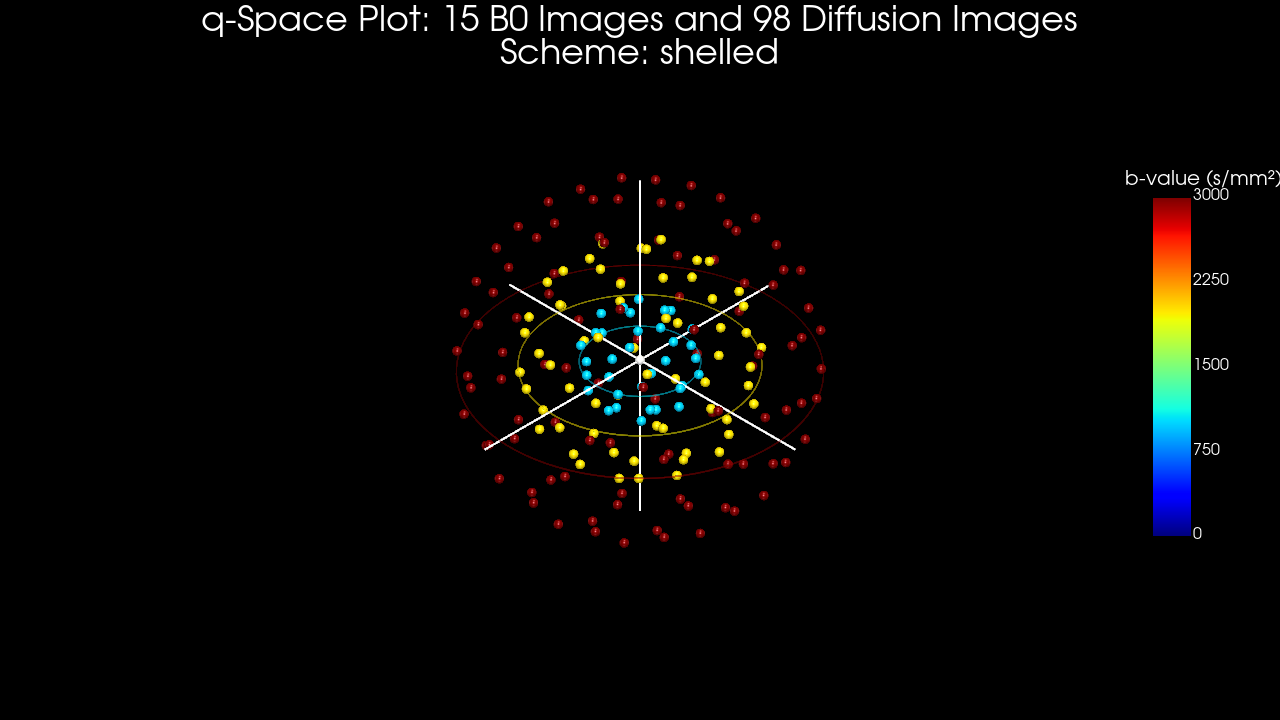

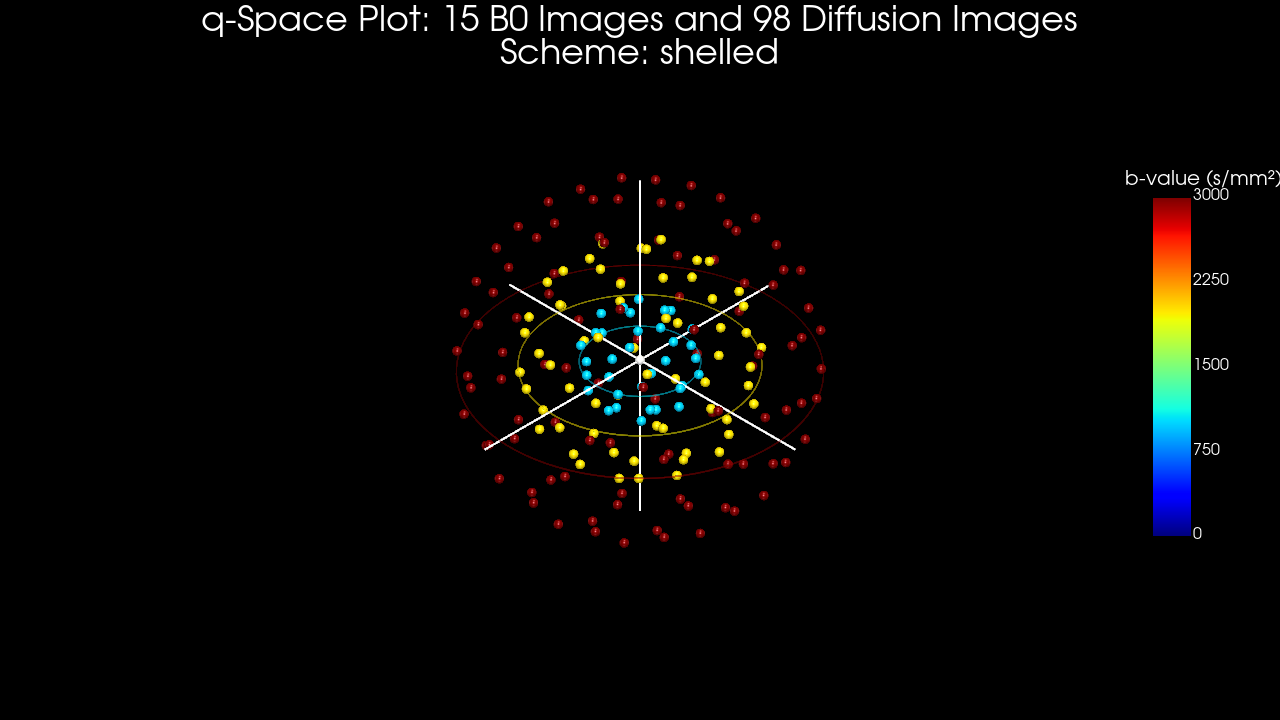

In [12]:
import clabtoolkit.dwitools as cltdwi
import os
os.environ["DISPLAY"] = ":1"   # check the number with: !ls /tmp/.X11-unix/
# ===================================================================
# --- Visualizing the Acquisition Scheme ---
# ===================================================================
print("\n" + "="*70)
print("--- Visualizing the Acquisition Scheme ---")
print("="*70 + "\n")

# Load the diffusion scheme
bvec_file = os.path.join(dwiDir, 'sub-0001_ses-01_dir-AP_run-01_dwi.bvec')
bval_file = os.path.join(dwiDir, 'sub-0001_ses-01_dir-AP_run-01_dwi.bval')

DiffusionScheme = cltdwi.DiffusionScheme.from_bvec_bval_files(bvec_file, bval_file)

# Plotting the diffusion scheme
DiffusionScheme.plot(use_notebook = True)

<a id="preprop-denoise"></a>
* 🔸 1.3. **`Noise Removal`**: Denoising


[↑ Back to Section 1 Outline](#sec1-preproc)

---

In [13]:
# ===================================================================
# --- Denoising ---
# ===================================================================

print("="*70)
print("--- Denoising ---")
print("="*70 + "\n")

# In case the previous conversion step was not performed copy the raw DWI data to the mrtrixDir folder:
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_raw.mif"):
    !cp $derivDir_proc/mrtrix/dwi_raw.mif $mrtrixDir/   

# First the noise removal (NOTE: this step can take around 15-30 minutes depending
# on the size of your data and the number of directions):
!dwidenoise $mrtrixDir/dwi_raw.mif $mrtrixDir/dwi_den.mif -noise $mrtrixDir/noise_level.mif -force -nthreads 2

--- Denoising ---

dwidenoise: [WARNING] existing output files will be overwritten
dwidenoise: [100%] preloading data for "/data/neurodesktop-storage/0-DataSet/BIDS/derivatives/mrtrix/dwi_raw.mif"...
dwidenoise: [100%] running MP-PCA denoising...


In [10]:
# ===================================================================
# --- Computing Residual Image ---
# ===================================================================
import os

print("\n" + "="*70)
print("--- Computing Residual Image ---")
print("="*70 + "\n")

# In case the previous denoising step was not performed copy the denoised image and the noise map to the mrtrixDir folder:
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/noise_level.mif"):
    !cp $derivDir_proc/mrtrix/noise_level.mif $mrtrixDir/


# from the original image (dwi_raw.mif).
!mrcalc $mrtrixDir/dwi_raw.mif $mrtrixDir/dwi_den.mif -subtract $mrtrixDir/residual.mif -force
# The -subtract option specifies the subtraction operation.

print("\n" + "="*70)
print("--- Visualizing the Results ---")
print("="*70 + "\n")

# Visualizing the results with mrview
!echo mrview $mrtrixDir/noise_level.mif -overlay.load $mrtrixDir/residual.mif -overlay.opacity 0.5



--- Computing Residual Image ---

mrcalc: [WARNING] existing output files will be overwritten
mrcalc: [100%] computing: (/data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/dwi_raw.mif - /data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/dwi_den.mif)[0K

--- Visualizing the Results ---

mrview /data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/noise_level.mif -overlay.load /data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/residual.mif -overlay.opacity 0.5


<a id="preprop-unringing"></a>
* 🔸 1.4. **`Unringing`**: Gibbs artifact correction

[↑ Back to Section 1 Outline](#sec1-preproc)

---

In [8]:
# ===================================================================
# --- Gibbs Ringing Removal ---
# ===================================================================

# In most cases, this corresponds to axes 0 and 1 (sagittal slices).

print("="*70)
print("--- Gibbs Ringing Removal ---")
print("="*70 + "\n")

# In case the previous denoising step was not performed copy the denoised image to the mrtrixDir folder:
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den.mif $mrtrixDir/

!mrdegibbs $mrtrixDir/dwi_den.mif $mrtrixDir/dwi_den_unr.mif -axes 0,1 -force

--- Gibbs Ringing Removal ---

mrdegibbs: [WARNING] existing output files will be overwritten
mrdegibbs: [100%] performing Gibbs ringing removal[0K


<a id="preprop-b0extraction"></a>
* 🔸 1.5. **`B0s Extraction`**: Extracting the B0 images

B0 images (images acquired without diffusion weighting, b=0 s/mm²) are used 
for various purposes including motion correction, distortion correction, and 
registration. This step extracts all B0 volumes from the diffusion dataset 
and optionally averages them to create a high-quality reference image.

[↑ Back to Section 1 Outline](#sec1-preproc)

---

In [9]:
# ===================================================================
# --- Extracting B0 Images ---
# ===================================================================
# File existence checks - copy from processed directory if needed
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den_unr_b0s.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den_unr_b0s.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_PA_b0s.mif"):
    !cp $derivDir_proc/mrtrix/dwi_PA_b0s.mif $mrtrixDir/


print("="*70)
print("--- Extracting B0 Images ---")
print("="*70 + "\n")

# In case the previous unringing step was not performed copy the denoised and unringed image to the mrtrixDir folder:
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den_unr.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den_unr.mif $mrtrixDir/

# Extract all B0 volumes from the denoised and unringed data
!dwiextract $mrtrixDir/dwi_den_unr.mif $mrtrixDir/dwi_den_unr_b0s.mif -bzero -force
# The -force option overwrites the output file if it already exists.

# Computing the mean B0 image for the PA acquisition
!dwiextract $mrtrixDir/dwi_PA.mif $mrtrixDir/dwi_PA_b0s.mif -bzero -force


--- Extracting B0 Images ---

dwiextract: [WARNING] existing output files will be overwritten
dwiextract: [100%] extracting volumes[0K
dwiextract: [WARNING] existing output files will be overwritten
dwiextract: [100%] extracting volumes[0K


In [10]:
# ===================================================================
# --- Averaging B0 Images ---
# ===================================================================

print("\n" + "="*70)
print("--- Averaging B0 Images ---")
print("="*70 + "\n")


# In case the previous B0 extraction step was not performed copy the extracted B0 images to the mrtrixDir folder:
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den_unr_b0s.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den_unr_b0s.mif $mrtrixDir/ 

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_PA_b0s.mif"):
    !cp $derivDir_proc/mrtrix/dwi_PA_b0s.mif $mrtrixDir/  

# calculated using the command:
!mrmath $mrtrixDir/dwi_den_unr_b0s.mif mean $mrtrixDir/mean_b0_AP.mif -axis 3 -force
# The -force option overwrites the output file if it already exists.

!mrmath $mrtrixDir/dwi_PA_b0s.mif mean $mrtrixDir/mean_b0_PA.mif -axis 3 -force
# The -force option overwrites the output file if it already exists.


--- Averaging B0 Images ---

mrmath: [WARNING] existing output files will be overwritten
mrmath: [100%] preloading data for "/data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/dwi_den_unr_b0s.mif"[0K
mrmath: [100%] computing mean along axis 3...[0K
mrmath: [WARNING] existing output files will be overwritten
mrmath: [100%] preloading data for "/data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/dwi_PA_b0s.mif"[0K
mrmath: [100%] computing mean along axis 3...[0K


<a id="preprop-moco"></a>
* 🔸 1.6. **`Motion, Distortion and Eddy Corrections`**: Motion and distortion corrections ⚠️ *(Do not run)*

**Motion and Distortion Correction**

Motion and distortion correction is performed using the `dwifslpreproc` command,  
which interfaces directly with the **FSL** package (ensure FSL is installed).

Internally, most of the processing is handled by FSL’s:

- `eddy`
- `topup` (when reverse phase-encoded images are available)

Both FSL and the relevant method papers should be cited when using this step.

---

**Sources of Artifacts in Diffusion MRI**

Diffusion MRI data are susceptible to:

- Subject motion during acquisition  
- Eddy current–induced distortions from rapidly switching gradients  
- Susceptibility-induced distortions causing geometric warping  
  (typically along the phase-encoding direction)

---

**Ways to Run `dwifslpreproc`**

`dwifslpreproc` can be run in two main configurations, depending on the data available.

---

**Option 1: Simple Motion and Eddy Current Correction**

This option is used when **reverse phase-encoded images are not available**.

- Corrects for subject motion and eddy currents only  
- Does **not** correct susceptibility-induced distortions  
- Faster and requires minimal additional data  
- Suitable for legacy datasets or acquisitions without reverse PE images  

Typical use case:
- Single phase-encoding direction
- No reverse PE b0 images acquired

---

**Option 2: Advanced Correction with Reverse Phase-Encoded B0s**

This is the **recommended approach** when reverse phase-encoded b0 images are available.

- Corrects motion, eddy currents, **and susceptibility-induced distortions**  
- Uses `topup` to estimate the susceptibility field  
- Requires b0 images acquired with **opposite phase-encoding directions**  
- Produces geometrically more accurate diffusion data  

Typical use case:
- Modern diffusion protocols
- Highest-quality preprocessing for tractography and modeling



[↑ Back to Section 1 Outline](#sec1-preproc)

---

In [11]:
# ===================================================================
# --- Simple Motion and Eddy Current Correction ---
# ===================================================================

# Option 1: Simple Motion and Eddy Current Correction

print("="*70)
print("--- Simple Motion and Eddy Current Correction ---")
print("="*70 + "\n")

# In case the previous unringing step was not performed copy the denoised and unringed image to the mrtrixDir folder:
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den_unr.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den_unr.mif $mrtrixDir/ 

# by eddy currents (without correcting for susceptibility distortions):
!dwifslpreproc $mrtrixDir/dwi_den_unr.mif $mrtrixDir/dwi_den_unr_preproc.mif -pe_dir AP -rpe_none -force
# bash: dwifslpreproc $mrtrixDir/dwi_den_unr.mif $mrtrixDir/dwi_den_unr_preproc.mif -pe_dir AP -rpe_none -force

# Note: -pe_dir AP indicates anterior-posterior phase encoding direction
# Note: -rpe_none means no reverse phase-encoded data is available


--- Simple Motion and Eddy Current Correction ---

dwifslpreproc: 
dwifslpreproc: Note that this script makes use of commands / algorithms that have relevant articles for citation; INCLUDING FROM EXTERNAL SOFTWARE PACKAGES. Please consult the help page (-help option) for more information.
dwifslpreproc: 
dwifslpreproc: [WARNING] Output file '/data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/dwi_den_unr_preproc.mif' already exists; will be overwritten at script completion
dwifslpreproc: Generated scratch directory: /data/Docencia/INDOs-2026/dwifslpreproc-tmp-ZXLSQM/
Command:  mrconvert /data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026/0-DataSet/BIDS/derivatives/mrtrix/dwi_den_unr.mif /data/Docencia/INDOs-2026/dwifslpreproc-tmp-ZXLSQM/dwi.mif -json_export /data/Docencia/INDOs-2026/dwifslpreproc-tmp-ZXLSQM/dwi.json
dwifslpreproc: Changing to scratch directory (/data/Docencia/INDOs-2026/dwifslpreproc-tmp-ZXLSQM/)
Command:  dirstat 

In [ ]:

# ===================================================================
# --- Advanced Correction with Reverse Phase-Encoded B0s ---
# ===================================================================

print("\n" + "="*70)
print("--- Advanced Correction with Reverse Phase-Encoded B0s ---")
print("="*70 + "\n")


# In case the previous unringing step was not performed copy the denoised and unringed image to the mrtrixDir folder:
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den_unr.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den_unr.mif $mrtrixDir/ 

# In case the previous unringing step was not performed copy the denoised and unringed image to the mrtrixDir folder:
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/mean_b0_PA.mif"):
    !cp $derivDir_proc/mrtrix/mean_b0_PA.mif $mrtrixDir/
    
# Copy averaged AP B0 image if not already present 
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/mean_b0_AP.mif"):
    !cp $derivDir_proc/mrtrix/mean_b0_AP.mif $mrtrixDir/

# The b0_pair.mif will contain both AP and PA encoded B0 images
!mrcat $mrtrixDir/mean_b0_AP.mif $mrtrixDir/mean_b0_PA.mif $mrtrixDir/b0_pair.mif -axis 3
# bash: mrcat $mrtrixDir/mean_b0_AP.mif $mrtrixDir/mean_b0_PA.mif $mrtrixDir/b0_pair.mif -axis 3

# This enables FSL's topup to estimate and correct susceptibility distortions
!dwifslpreproc $mrtrixDir/dwi_den_unr.mif $mrtrixDir/dwi_den_unr_preproc.mif -pe_dir AP -rpe_pair -se_epi $mrtrixDir/b0_pair.mif -eddy_options " --slm=linear" -force
# bash: dwifslpreproc $mrtrixDir/dwi_den_unr.mif $mrtrixDir/dwi_den_unr_preproc.mif -pe_dir AP -rpe_pair -se_epi $mrtrixDir/b0_pair.mif -eddy_options " --slm=linear" -force


print("\n" + "="*70)
print("--- Visualizing the Preprocessed Data ---")
print("="*70 + "\n")

# Visualizing the results with mrview
!echo mrview $mrtrixDir/dwi_den_unr_preproc.mif -overlay.load $mrtrixDir/mean_b0_AP.mif -overlay.opacity 0.5
# The -overlay.opacity option sets the opacity of the overlays to 50% for better visualization.


print("\n" + "="*70)
print("--- Important Notes on Phase Encoding Direction ---")
print("="*70 + "\n")

# complex scenarios (e.g., all DWIs with reverse phase encoding).

print("\n✓ Motion, distortion, and eddy current correction complete!")

<a id="preprop-bias"></a>
* 🔸 1.7. **`Bias Field Correction`**: Correcting field inhomogeneity effects

**Field Inhomogeneity (Bias Field) Correction**

Field inhomogeneity, also known as a **bias field**, is a low-frequency intensity variation  
across the image caused by imperfections in the MRI scanner’s magnetic field.

This effect can negatively impact later processing steps, particularly:

- Brain mask estimation  
- Fiber orientation modeling  

---

**Why Apply Bias Field Correction?**

Applying bias field correction can improve the performance of intermediate steps,  
especially **brain mask estimation**.

This step is **optional** and should be included based on visual inspection and  
whether brain masking performs adequately **with or without** correction.

---

**Bias Field Correction with ANTs**

Bias field correction can be performed using:

- `dwibiascorrect ants`

This command interfaces with the **ANTs (Advanced Normalization Tools)** package  
(ensure ANTs is installed).

Internally, the correction is performed using:

- `N4BiasFieldCorrection`

When using this step, be sure to **cite both ANTs and the relevant method paper**.


**Evaluating Bias Field Correction**

After performing bias field correction, it is recommended to **check the output**  
and ensure that the field inhomogeneity has been corrected **without introducing extreme values**,  
particularly near the edges of the field of view. Extreme values can negatively affect:

- Brain mask estimation  
- Fiber orientation distribution (FOD) calculation  

---

**Important Considerations**

1. **Visual Inspection**  
   Look for:  
   - Smooth intensity variation across the image (**good**)  
   - Extreme bright or dark values at edges (**bad** — may indicate the step should be skipped)  
   - Overall improved intensity homogeneity (**good**)  

2. **Artifacts or Extreme Values**  
   - If artifacts are observed, you can **skip this step** and proceed directly with `dwi_den_unr_preproc.mif`  
   - Brain mask estimation may still work adequately without bias correction  

3. **Uncertainty**  
   - If unsure, continue with the **next step (brain mask estimation)** and evaluate the results  
   - You can always return and re-run **without bias correction** if necessary  

4. **Requirements**  
   - **ANTs** (Advanced Normalization Tools) must be installed  
   - **Citation:** Tustison et al. (2010), *N4ITK: Improved N3 Bias Correction*



[↑ Back to Section 1 Outline](#sec1-preproc)

---

In [11]:
# ===================================================================
# --- Bias Field Correction using ANTs N4 ---
# ===================================================================

print("="*70)
print("--- Bias Field Correction using ANTs N4 ---")
print("="*70 + "\n")

# In case the previous motion and distortion correction step was not performed copy the preprocessed DWI data to the mrtrixDir folder:
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den_unr_preproc.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den_unr_preproc.mif $mrtrixDir/

# Perform bias field correction using ANTs N4
!dwibiascorrect ants $mrtrixDir/dwi_den_unr_preproc.mif $mrtrixDir/dwi_den_unr_preproc_unb.mif -force
# The -force option overwrites the output file if it already exists.

print("\n" + "="*70)
print("--- Quality Check ---")
print("="*70 + "\n")

# Visualize the bias-corrected image to check for artifacts
!echo mrview $mrtrixDir/dwi_den_unr_preproc_unb.mif
# bash: mrview $mrtrixDir/dwi_den_unr_preproc_unb.mif

# !echo mrview $mrtrixDir/dwi_den_unr_preproc.mif $mrtrixDir/dwi_den_unr_preproc_unb.mif

print("\n✓ Bias field correction complete!")
print("   Remember to visually inspect the output before proceeding.")

--- Bias Field Correction using ANTs N4 ---

dwibiascorrect: 
dwibiascorrect: Note that this script makes use of commands / algorithms that have relevant articles for citation; INCLUDING FROM EXTERNAL SOFTWARE PACKAGES. Please consult the help page (-help option) for more information.
dwibiascorrect: 
dwibiascorrect: [WARNING] Output file '/data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/dwi_den_unr_preproc_unb.mif' already exists; will be overwritten at script completion
dwibiascorrect: Generated scratch directory: /data/Docencia/INDOs-2026/wg3-ts2026-aleman-gomez/HandsOn/dwibiascorrect-tmp-FWSZ0N/
Command:  mrconvert /data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026/0-DataSet/BIDS/derivatives/mrtrix/dwi_den_unr_preproc.mif /data/Docencia/INDOs-2026/wg3-ts2026-aleman-gomez/HandsOn/dwibiascorrect-tmp-FWSZ0N/in.mif
dwibiascorrect: Changing to scratch directory (/data/Docencia/INDOs-2026/wg3-ts2026-aleman-gomez/HandsOn/dwibiasco

<a id="preprop-bmask"></a>
* 🔸 1.8. **`Brain Mask Estimation`**: Brain mask extraction

**Brain Mask**

A brain mask is a **binary image** where:

- Voxels with value **1** are considered **inside the brain**  
- Voxels with value **0** are considered **background**

---

**Uses of a Brain Mask**

- Reduces computation time by analyzing **only brain voxels**  
- Improves result quality by restricting analysis to **regions of interest**  
- Prevents processing artifacts from **non-brain tissue**  
- Essential for many downstream steps, such as:  
  - Fiber orientation distribution (FOD) estimation  
  - Tractography  
  - Other diffusion analyses  

---

**How to Obtain a Brain Mask**

- MRtrix: `dwi2mask`
- Synthstrip: `mri_synthstrip`
- FSL: `bet` or `bet2`


[↑ Back to Section 1 Outline](#sec1-preproc)

---

In [12]:
# ===================================================================
# --- Brain Mask Estimation using MRtrix ---
# ===================================================================


print("="*70)
print("--- Brain Mask Estimation using MRtrix ---")
print("="*70 + "\n")

# In case the previous bias correction step was not performed copy the bias-corrected DWI data to the mrtrixDir folder:
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den_unr_preproc_unb.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den_unr_preproc_unb.mif $mrtrixDir/


# The dwi2mask algorithm uses FSL's bet2 by default
!dwi2mask $mrtrixDir/dwi_den_unr_preproc_unb.mif $mrtrixDir/dwi_mask.mif -force
# The -force option overwrites the output file if it already exists.

print("\n" + "="*70)
print("--- Visualizing and Quality Checking the Brain Mask ---")
print("="*70 + "\n")

# Overlay the mask on the DWI data to verify it correctly covers the brain
!echo mrview $mrtrixDir/dwi_den_unr_preproc_unb.mif -overlay.load $mrtrixDir/dwi_mask.mif
# The -overlay.load option loads the brain mask as an overlay on top of the DWI image.


print("\n" + "="*70)
print("--- Quality Control and Troubleshooting ---")
print("="*70 + "\n")

print("✓ Brain mask estimation complete!")
print("   Ensure the mask accurately encompasses the brain region.")
print("   If necessary, consider adjusting parameters or using alternative methods (Synthstrip).")
print("   A good brain mask is crucial for accurate downstream analyses.")

--- Brain Mask Estimation using MRtrix ---

dwi2mask: [WARNING] existing output files will be overwritten
dwi2mask: [100%] preloading data for "/data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/dwi_den_unr_preproc_unb.mif"[0K
dwi2mask: [done] computing dwi brain mask[0K
dwi2mask: [done] applying mask cleaning filter[0K

--- Visualizing and Quality Checking the Brain Mask ---

mrview /data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/dwi_den_unr_preproc_unb.mif -overlay.load /data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/dwi_mask.mif

--- Quality Control and Troubleshooting ---

✓ Brain mask estimation complete!
   Ensure the mask accurately encompasses the brain region.
   If necessary, consider adjusting parameters or using alternative methods (Synthstrip).
   A good brain mask is crucial for accurate downstream analyses.


<a id="preprop-interp"></a>
* 🔸 1.9. **`Interpolation (Optional)`**: Upsampling to isotropic resolution

**Diffusion MRI Upsampling / Resampling**

Resampling (upsampling) diffusion MRI images before **Constrained Spherical Deconvolution (CSD)** can reveal finer structural details and improve:

- Image registration  
- Template construction  
- Tractography

---

**Important Consideration**

Upsampling increases voxel count exponentially. For example, doubling all voxel dimensions generates **8× more voxels**, increasing:

- Memory usage  
- Processing time  
- Storage requirements  

---

**Brain Mask Interpolation**

- Brain masks must be interpolated to match the new resolution  
- Use **`-interp nearest`** for binary masks to preserve 0/1 values  
- Other interpolation methods create invalid intermediate values  

---

**Key Points**

1. **When to Upsample**  
   - Before fODF estimation  
   - For improved registration or template creation  
   - For high-resolution tractography  

2. **Interpolation Methods**  
   - **Cubic B-spline:** for continuous data (DWI)  
   - **Nearest neighbor (`-interp nearest`):** for masks/parcellations  
   - **Linear:** faster but less smooth  

3. **Voxel Size**  
   - Typical choices: 1.0, 1.25, 1.5 mm isotropic  
   - Avoid extreme oversampling (e.g., 0.5 mm → 64× more data)  
   - Balance detail with computational cost  

4. **Downstream Impact**  
   - All later processing uses upsampled data  
   - Increases memory and runtime  
   - Can improve fODF detail  

5. **Optional Step**  
   - Skip if desired; continue with `dwi_den_unr_preproc_unb.mif` and `dwi_mask.mif`  
   - If upsampled, use `dwi_den_unr_preproc_unb_upsampled.mif` and `dwi_mask_upsampled.mif`


[↑ Back to Section 1 Outline](#sec1-preproc)

---

In [15]:
# ===================================================================
# --- Upsampling Diffusion Data to Isotropic Resolution ---
# ===================================================================


print("="*70)
print("--- Upsampling Diffusion Data to Isotropic Resolution ---")
print("="*70 + "\n")

# In case the previous bias correction step was not performed copy the bias-corrected DWI data to the mrtrixDir folder:
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den_unr_preproc_unb.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den_unr_preproc_unb.mif $mrtrixDir/

# Copy the mask as well
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_mask.mif"):
    !cp $derivDir_proc/mrtrix/dwi_mask.mif $mrtrixDir/

# By default, mrgrid uses cubic b-spline interpolation for continuous data
!mrgrid $mrtrixDir/dwi_den_unr_preproc_unb.mif regrid $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -voxel 1.5 -force
# By default, mrgrid uses cubic b-spline interpolation for continuous data.

print("\n" + "="*70)
print("--- Upsampling Brain Mask ---")
print("="*70 + "\n")

# IMPORTANT: Use -interp nearest for binary masks to preserve discrete values (0 and 1)
# Using other interpolation methods would create intermediate values between 0 and 1
!mrgrid $mrtrixDir/dwi_mask.mif regrid $mrtrixDir/dwi_mask_upsampled.mif -voxel 1.5 -interp nearest -force
# The -interp nearest option specifies nearest neighbor interpolation for binary masks.


print("\n" + "="*70)
print("--- Visualizing Upsampled Data ---")
print("="*70 + "\n")

# Visualize the upsampled diffusion data with the upsampled mask overlay
!echo mrview $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -overlay.load $mrtrixDir/dwi_mask_upsampled.mif
# This allows you to visually verify that the upsampled mask aligns correctly with the upsampled diffusion data.


print("\n" + "="*70)
print("--- Verifying Resolution Change ---")
print("="*70 + "\n")

# You can verify the resolution change with mrinfo
print("\nOriginal resolution:")
!mrinfo $mrtrixDir/dwi_mask.mif | grep "Voxel size"
# bash: mrinfo $mrtrixDir/dwi_mask.mif | grep "Voxel size"

print("\nUpsampled resolution:")
!mrinfo $mrtrixDir/dwi_mask_upsampled.mif | grep "Voxel size"
# bash: mrinfo $mrtrixDir/dwi_mask_upsampled.mif | grep "Voxel size"

print("\n✓ Interpolation complete!")
print("   Remember to use the upsampled images in all subsequent processing steps.")

--- Upsampling Diffusion Data to Isotropic Resolution ---

mrgrid: [WARNING] existing output files will be overwritten
mrgrid: [100%] reslicing "/data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/dwi_den_unr_preproc_unb.mif"[0K

--- Upsampling Brain Mask ---

mrgrid: [WARNING] existing output files will be overwritten
mrgrid: [100%] reslicing "/data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/dwi_mask.mif"[0K

--- Visualizing Upsampled Data ---

/opt/mrtrix3-3.0.4/bin/mrview: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_2.38' not found (required by /.singularity.d/libs/libGLdispatch.so.0)
/opt/mrtrix3-3.0.4/bin/mrview: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_2.34' not found (required by /.singularity.d/libs/libGLdispatch.so.0)
/opt/mrtrix3-3.0.4/bin/mrview: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_2.38' not found (required by /.singularity.d/libs/libGLX.so.0)
/opt/mrtrix3-3.0.

<a id="sec2-intravox"></a>
## Section 2: Intravoxel Modeling and fODF Estimation

In this section we estimate the fiber orientation distribution functions using various diffusion models.

**Section Contents:**
* 🔸 2.1. [**Diffusion Tensor**](#fodf-tensor): Computing diffusion tensor and scalar maps
* 🔸 2.2. [**Response Function**](#fodf-response): Calculation of the response function
* 🔸 2.3. [**CSD Estimation**](#fodf-csd): fODF estimation using Constrained Spherical Deconvolution
* 🔸 2.4. [**Intensity Normalization**](#fodf-normalize): Multi-tissue intensity normalization
* 🔸 2.5. [**Visualization**](#fodf-visualization): Directionally-encoded color maps

[↑ Back to Tutorial Outline](#tutorial-outline)

---


<a id="fodf-tensor"></a>
* 🔸 2.1. **`Diffusion Tensor`**: Computing diffusion tensor and scalar maps

**Diffusion Tensor Model (DTI)**

The diffusion tensor model describes water diffusion as a **3D Gaussian process**.  
It is the simplest and most widely used model in diffusion MRI analysis.

---

**Important Consideration**

- The tensor model is **valid only for relatively low b-values** (typically ≤ 1000–1500 s/mm²)  
- At higher b-values, **non-Gaussian diffusion effects** make the tensor model inaccurate  
- Therefore, only **shells with b-values < 1500 s/mm²** are extracted for DTI analysis

**Interpretation of DTI Scalar Maps**

---

**1. Fractional Anisotropy (FA)**

- Range: 0 (isotropic) to 1 (highly anisotropic)  
- **High FA (~0.7–0.9):** white matter tracts (organized fiber bundles)  
- **Medium FA (~0.3–0.5):** gray matter, crossing fibers  
- **Low FA (~0.1–0.2):** CSF, edema, free water  
- Most commonly used DTI metric in research and clinical studies  

---

**2. Mean Diffusivity (MD / ADC)**

- Units: mm²/s (typical range: 0.0007–0.003)  
- **High MD:** CSF, edema, regions of increased water content  
- **Low MD:** white matter, areas of restricted diffusion  
- Useful for detecting edema, cell swelling, and tissue density changes  

---

**3. Principal Eigenvector (vector.mif)**

- Shows the **primary diffusion direction** at each voxel  
- Aligns with fiber bundle orientation in white matter  
- RGB color coding: **Red = Left–Right**, **Green = Anterior–Posterior**, **Blue = Superior–Inferior**  
- Forms the basis for **tractography algorithms**  

---

**4. Why Use Low b-Values for DTI**

- DTI assumes **Gaussian diffusion** (monoexponential signal decay)  
- This assumption breaks down at **high b-values (b > 1500)**  
- Using low b-values ensures **accurate tensor fitting**  
- Higher b-values are better suited for advanced models (fODF, NODDI, etc.)  

---

**Quality Checks**

1. **FA Values**  
   - 0.7–0.9 in major white matter tracts (e.g., corpus callosum, internal capsule)  
   - 0.1–0.3 in gray matter  
   - Near 0 in ventricles (CSF)  

2. **MD Values**  
   - ~0.0007 mm²/s in white matter  
   - ~0.0010 mm²/s in gray matter  
   - ~0.0030 mm²/s in CSF  

3. **Visual Inspection**  
   - Check for artifacts (signal dropouts, residual motion)  
   - Verify tensor ellipsoids align with known anatomy  
   - Look for unrealistic FA values (>1.0 or negative)



[↑ Back to Section 2 Outline](#sec2-intravox)

---

In [13]:
# ===================================================================
# --- Diffusion Tensor Estimation ---
# ===================================================================

print("="*70)
print("--- Extracting Low b-value Shells (b < 1500) ---")
print("="*70 + "\n")

# In case the previous upsampling step was not performed copy the upsampled DWI data and mask to the mrtrixDir folder:
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den_unr_preproc_unb_upsampled.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/

# First, check which b-value shells are available in your data
print("Available b-value shells in the data:")
!mrinfo $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -shell_bvalues
# The -shell_bvalues option lists the unique b-values present in the dataset.

print("\n")

# The -shells option automatically selects shells below the specified threshold
!dwiextract $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/dwi_b1500.mif -shells 0,1000 -force
# The -shells option specifies which b-value shells to extract.

# Note: Adjust the shell values (0,1000) based on your actual acquisition
# You can also use: -shells 0,1500 or specify exact b-values from mrinfo output

print("\n" + "="*70)
print("--- Computing Diffusion Tensor ---")
print("="*70 + "\n")

# The tensor is a 3x3 symmetric matrix at each voxel describing the diffusion ellipsoid
!dwi2tensor $mrtrixDir/dwi_b1500.mif -mask $mrtrixDir/dwi_mask_upsampled.mif $mrtrixDir/tensor.mif -force
# The -force option overwrites the output file if it already exists.


print("\n" + "="*70)
print("--- Extracting Scalar Maps from Tensor ---")
print("="*70 + "\n")

!tensor2metric $mrtrixDir/tensor.mif -fa $mrtrixDir/fa.mif -adc $mrtrixDir/md.mif -vector $mrtrixDir/vector.mif -force
# The -force option overwrites the output files if they already exist.
# The -fa option computes Fractional Anisotropy (FA) map.
# The -adc option computes Mean Diffusivity (MD) map.
# The -vector option computes the principal diffusion direction vectors.

print("\n" + "="*70)
print("--- Visualizing Tensor and Scalar Maps ---")
print("="*70 + "\n")

# Display FA map with tensor ellipsoids overlaid
!echo mrview $mrtrixDir/fa.mif -odf.load_tensor $mrtrixDir/tensor.mif
# The -odf.load_tensor option loads the diffusion tensor for ellipsoid visualization.

# Convert fa.mif and md.mif to NIfTI for compatibility with other software if needed
!mrconvert -force $mrtrixDir/fa.mif $mrtrixDir/fa.nii.gz
!mrconvert -force $mrtrixDir/md.mif $mrtrixDir/md.nii.gz

# !echo mrview $mrtrixDir/fa.mif

# !echo mrview $mrtrixDir/md.mif

# !echo mrview $mrtrixDir/vector.mif


print("\n✓ Diffusion tensor computation complete!")
print("   FA and MD maps are ready for analysis or registration.")
print("   Tensor is ready for basic deterministic tractography.")

--- Extracting Low b-value Shells (b < 1500) ---

Available b-value shells in the data:
0 1000 2000 3000 


dwiextract: [WARNING] existing output files will be overwritten
dwiextract: [100%] extracting volumes[0K

--- Computing Diffusion Tensor ---

dwi2tensor: [WARNING] existing output files will be overwritten
dwi2tensor: [100%] computing tensors[0K

--- Extracting Scalar Maps from Tensor ---

tensor2metric: [WARNING] existing output files will be overwritten
tensor2metric: [100%] computing metrics[0K

--- Visualizing Tensor and Scalar Maps ---

mrview /data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/fa.mif -odf.load_tensor /data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/tensor.mif
mrconvert: [WARNING] existing output files will be overwritten
mrconvert: [100%] copying from "/data/Work...S/derivatives/mrtrix/fa.mif" to "/data/Work...erivatives/mrtrix/fa.nii.gz"[0K
mrconvert: [100%] compre

<a id="preprop-bmask-part2"></a>
* 🔸 1.8. **`Brain Mask Estimation`**: Brain mask extraction

**Brain Mask**

A brain mask is a **binary image** where:

- Voxels with value **1** are considered **inside the brain**  
- Voxels with value **0** are considered **background**

---

**Uses of a Brain Mask**

- Reduces computation time by analyzing **only brain voxels**  
- Improves result quality by restricting analysis to **regions of interest**  
- Prevents processing artifacts from **non-brain tissue**  
- Essential for many downstream steps, such as:  
  - Fiber orientation distribution (FOD) estimation  
  - Tractography  
  - Other diffusion analyses  

---

**How to Obtain a Brain Mask**

- MRtrix: `dwi2mask`
- Synthstrip: `mri_synthstrip`
- FSL: `bet` or `bet2`


[↑ Back to Section 1 Outline](#sec1-preproc)

---

In [17]:
# ===================================================================
# --- Brain Mask Estimation using MRtrix ---
# ===================================================================


print("="*70)
print("--- Brain Mask Estimation using MRtrix ---")
print("="*70 + "\n")

# In case the previous bias correction step was not performed copy the bias-corrected DWI data to the mrtrixDir folder:
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den_unr_preproc_unb.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den_unr_preproc_unb.mif $mrtrixDir/


# The dwi2mask algorithm uses FSL's bet2 by default
!dwi2mask $mrtrixDir/dwi_den_unr_preproc_unb.mif $mrtrixDir/dwi_mask.mif -force
# The -force option overwrites the output file if it already exists.

print("\n" + "="*70)
print("--- Visualizing and Quality Checking the Brain Mask ---")
print("="*70 + "\n")

# Overlay the mask on the DWI data to verify it correctly covers the brain
!echo mrview $mrtrixDir/dwi_den_unr_preproc_unb.mif -overlay.load $mrtrixDir/dwi_mask.mif
# The -overlay.load option loads the brain mask as an overlay on top of the DWI image.


print("\n" + "="*70)
print("--- Quality Control and Troubleshooting ---")
print("="*70 + "\n")

print("✓ Brain mask estimation complete!")
print("   Ensure the mask accurately encompasses the brain region.")
print("   If necessary, consider adjusting parameters or using alternative methods (Synthstrip).")
print("   A good brain mask is crucial for accurate downstream analyses.")

--- Brain Mask Estimation using MRtrix ---

dwi2mask: [WARNING] existing output files will be overwritten
dwi2mask: [100%] preloading data for "/data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/dwi_den_unr_preproc_unb.mif"[0K
dwi2mask: [done] computing dwi brain mask[0K
dwi2mask: [done] applying mask cleaning filter[0K

--- Visualizing and Quality Checking the Brain Mask ---

/opt/mrtrix3-3.0.4/bin/mrview: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_2.38' not found (required by /.singularity.d/libs/libGLdispatch.so.0)
/opt/mrtrix3-3.0.4/bin/mrview: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_2.34' not found (required by /.singularity.d/libs/libGLdispatch.so.0)
/opt/mrtrix3-3.0.4/bin/mrview: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_2.38' not found (required by /.singularity.d/libs/libGLX.so.0)
/opt/mrtrix3-3.0.4/bin/mrview: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_2.34' not found (required by /.singularity.d/libs/libGL

<a id="preprop-interp-part2"></a>
* 🔸 1.9. **`Interpolation (Optional)`**: Upsampling to isotropic resolution

**Diffusion MRI Upsampling / Resampling**

Resampling (upsampling) diffusion MRI images before **Constrained Spherical Deconvolution (CSD)** can reveal finer structural details and improve:

- Image registration  
- Template construction  
- Tractography

---

**Important Consideration**

Upsampling increases voxel count exponentially. For example, doubling all voxel dimensions generates **8× more voxels**, increasing:

- Memory usage  
- Processing time  
- Storage requirements  

---

**Brain Mask Interpolation**

- Brain masks must be interpolated to match the new resolution  
- Use **`-interp nearest`** for binary masks to preserve 0/1 values  
- Other interpolation methods create invalid intermediate values  

---

**Key Points**

1. **When to Upsample**  
   - Before fODF estimation  
   - For improved registration or template creation  
   - For high-resolution tractography  

2. **Interpolation Methods**  
   - **Cubic B-spline:** for continuous data (DWI)  
   - **Nearest neighbor (`-interp nearest`):** for masks/parcellations  
   - **Linear:** faster but less smooth  

3. **Voxel Size**  
   - Typical choices: 1.0, 1.25, 1.5 mm isotropic  
   - Avoid extreme oversampling (e.g., 0.5 mm → 64× more data)  
   - Balance detail with computational cost  

4. **Downstream Impact**  
   - All later processing uses upsampled data  
   - Increases memory and runtime  
   - Can improve fODF detail  

5. **Optional Step**  
   - Skip if desired; continue with `dwi_den_unr_preproc_unb.mif` and `dwi_mask.mif`  
   - If upsampled, use `dwi_den_unr_preproc_unb_upsampled.mif` and `dwi_mask_upsampled.mif`


[↑ Back to Section 1 Outline](#sec1-preproc)

---

In [14]:
# ===================================================================
# --- Upsampling Diffusion Data to Isotropic Resolution ---
# ===================================================================


print("="*70)
print("--- Upsampling Diffusion Data to Isotropic Resolution ---")
print("="*70 + "\n")

# In case the previous bias correction step was not performed copy the bias-corrected DWI data to the mrtrixDir folder:
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den_unr_preproc_unb.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den_unr_preproc_unb.mif $mrtrixDir/

# Copy the mask as well
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_mask.mif"):
    !cp $derivDir_proc/mrtrix/dwi_mask.mif $mrtrixDir/

# By default, mrgrid uses cubic b-spline interpolation for continuous data
!mrgrid $mrtrixDir/dwi_den_unr_preproc_unb.mif regrid $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -voxel 1.5 -force
# By default, mrgrid uses cubic b-spline interpolation for continuous data.

print("\n" + "="*70)
print("--- Upsampling Brain Mask ---")
print("="*70 + "\n")

# IMPORTANT: Use -interp nearest for binary masks to preserve discrete values (0 and 1)
# Using other interpolation methods would create intermediate values between 0 and 1
!mrgrid $mrtrixDir/dwi_mask.mif regrid $mrtrixDir/dwi_mask_upsampled.mif -voxel 1.5 -interp nearest -force
# The -interp nearest option specifies nearest neighbor interpolation for binary masks.


print("\n" + "="*70)
print("--- Visualizing Upsampled Data ---")
print("="*70 + "\n")

# Visualize the upsampled diffusion data with the upsampled mask overlay
!echo mrview $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -overlay.load $mrtrixDir/dwi_mask_upsampled.mif
# This allows you to visually verify that the upsampled mask aligns correctly with the upsampled diffusion data.


print("\n" + "="*70)
print("--- Verifying Resolution Change ---")
print("="*70 + "\n")

# You can verify the resolution change with mrinfo
print("\nOriginal resolution:")
!mrinfo $mrtrixDir/dwi_mask.mif | grep "Voxel size"
# bash: mrinfo $mrtrixDir/dwi_mask.mif | grep "Voxel size"

print("\nUpsampled resolution:")
!mrinfo $mrtrixDir/dwi_mask_upsampled.mif | grep "Voxel size"
# bash: mrinfo $mrtrixDir/dwi_mask_upsampled.mif | grep "Voxel size"

print("\n✓ Interpolation complete!")
print("   Remember to use the upsampled images in all subsequent processing steps.")

--- Upsampling Diffusion Data to Isotropic Resolution ---

mrgrid: [WARNING] existing output files will be overwritten
mrgrid: [100%] reslicing "/data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/dwi_den_unr_preproc_unb.mif"[0K

--- Upsampling Brain Mask ---

mrgrid: [WARNING] existing output files will be overwritten
mrgrid: [100%] reslicing "/data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/dwi_mask.mif"[0K

--- Visualizing Upsampled Data ---

mrview /data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/dwi_den_unr_preproc_unb_upsampled.mif -overlay.load /data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/dwi_mask_upsampled.mif

--- Verifying Resolution Change ---


Original resolution:
  Voxel size:        2.5 x 2.5 x 2.5

Upsampled resolution:
  Voxel size:        1.5 x 1.5 x 1.5

✓ Interpolation complet

## =======================================   Part II ============================================================

<a id="sec2-intravox-part2"></a>
## Section 2: Intravoxel Modeling and fODF Estimation

In this section we estimate the fiber orientation distribution functions using various diffusion models.

**Section Contents:**
* 🔸 2.1. [**Diffusion Tensor**](#fodf-tensor): Computing diffusion tensor and scalar maps
* 🔸 2.2. [**Response Function**](#fodf-response): Calculation of the response function
* 🔸 2.3. [**CSD Estimation**](#fodf-csd): fODF estimation using Constrained Spherical Deconvolution
* 🔸 2.4. [**Intensity Normalization**](#fodf-normalize): Multi-tissue intensity normalization
* 🔸 2.5. [**Visualization**](#fodf-visualization): Directionally-encoded color maps

[↑ Back to Tutorial Outline](#tutorial-outline)

---


<a id="fodf-response"></a>
* 🔸 2.2. **`Response Function`**: Calculation of the response function

**Response Function for CSD**

The **response function** describes how a **single fiber population** appears in the diffusion MRI signal.  
It is the **building block** that CSD uses to decompose the signal into multiple fiber orientations.

- In white matter, it models voxels containing **one coherent fiber orientation**  
- The algorithm automatically selects **single-fiber voxels**, typically in major tracts like the corpus callosum  

---

**Single-Shell vs Multi-Shell**

1. **Single-Shell (`dwi2response fa`)**  
   - For data with **one b-value (+ b=0)**  
   - Uses **FA threshold** to find single-fiber voxels  
   - Simpler, only models white matter  
   - Suitable for basic single-tissue CSD  

2. **Multi-Shell (`dwi2response dhollander`)**  
   - For data with **2+ b-value shells**  
   - Automatically segments **WM, GM, and CSF**  
   - Required for **Multi-Shell Multi-Tissue CSD (MSMT-CSD)**  
   - Recommended when multi-shell data are available  

---

**Expected Characteristics:**

- **WM:** Strong anisotropy → cylinder-shaped in `shview` 
- **GM:** Mild anisotropy → slightly elongated sphere in `shview`  
- **CSF:** Isotropic → perfect sphere in `shview` (only l=0 non-zero)  

---

**Quality Checks**

1. **Voxel Selection (`voxels.mif` overlay)**  
   - WM: major tracts (corpus callosum, internal capsule)  
   - GM: cortex or deep grey matter  
   - CSF: ventricles or sulci  
   - Typical numbers: 300+ voxels for WM, 100+ for GM/CSF  
   - Avoid voxels at edges, near air/tissue interfaces, or artifacts  

2. **Response Function Shape (`shview`)**  
   - WM: elongated
   - GM: nearly spherical with slight elongation
   - CSF: spherical 

3. **Across b-Values**  
   - Signal decreases with increasing b-value  
   - Shape remains consistent  
   - WM anisotropy may increase slightly with b-value  

4. **Red Flags**  
   - Spherical WM response → isotropic contamination  
   - Elongated CSF response → partial voluming  
   - Very few selected voxels (<100) or clustered in one region  
   - Unrealistic coefficients (negative, >5.0)  

5. **Troubleshooting**  
   - WM response incorrect → check brain mask, preprocessing quality, or try `dwi2response tournier`  
   - Insufficient voxels → check data quality, SNR, b-values, or consider manual estimation  

---

**Decision Guide**

- Use **`dwi2response fa` (single-shell)** when:  
  - Only one b-value (+ b=0) is available  
  - Standard single-tissue CSD is planned  
  - Computational resources are limited  

- Use **`dwi2response dhollander` (multi-shell)** when:  
  - 2+ b-value shells are available  
  - MSMT-CSD is planned (recommended)  
  - Improved modeling of GM and CSF is desired  
  - Tissue-specific fODFs are needed  

**Recommendation:**  
If multi-shell data are available, **always use `dwi2response dhollander`** for the most accurate and comprehensive tissue modeling.




[↑ Back to Section 2 Outline](#sec2-intravox)

---

In [15]:
# ===================================================================
# --- Response Function Estimation ---
# ===================================================================
# File existence checks - copy from processed directory if needed
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den_unr_preproc_unb_upsampled.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_mask_upsampled.mif"):
    !cp $derivDir_proc/mrtrix/dwi_mask_upsampled.mif $mrtrixDir/

print("="*70)
print("--- Checking Available b-value Shells ---")
print("="*70 + "\n")

# First, verify which b-value shells are available in your data
print("Available b-value shells:")
!mrinfo $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -shell_bvalues
# bash: mrinfo $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -shell_bvalues
# The -shell_bvalues option lists the unique b-values present in the dataset.

print("\n" + "="*70)
print("--- APPROACH 1: Single-Shell Response Function (FA-based) ---")
print("="*70 + "\n")

# (typically FA > 0.7 in highly coherent white matter tracts)

!dwi2response fa -voxels $mrtrixDir/voxels.mif $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/response_wm_sshell.txt -shells 0,1000 -force
# The -force option overwrites the output files if they already exist.
# The -shells option specifies which b-value shells to use for response function estimation.
# Note: Adjust the shell values (0,1000) based on your actual acquisition


print("\nVisualizing voxels selected for single-shell response function:")

# Overlay the selected voxels on the DWI data to see where they were chosen from
!echo mrview $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -overlay.load $mrtrixDir/voxels.mif
# The -overlay.load option loads the selected voxels as an overlay.

print("\nVisualizing the single-shell response function:")

# View the response function shape
!echo shview $mrtrixDir/response_wm_sshell.txt
# bash: shview $mrtrixDir/response_wm_sshell.txt



--- Checking Available b-value Shells ---

Available b-value shells:
0 1000 2000 3000 

--- APPROACH 1: Single-Shell Response Function (FA-based) ---

dwi2response: 
dwi2response: Note that this script makes use of commands / algorithms that have relevant articles for citation. Please consult the help page (-help option) for more information.
dwi2response: 
dwi2response: [WARNING] Output file '/data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/voxels.mif' already exists; will be overwritten at script completion
dwi2response: [WARNING] Output file '/data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/response_wm_sshell.txt' already exists; will be overwritten at script completion
dwi2response: Generated scratch directory: /data/Docencia/INDOs-2026/wg3-ts2026-aleman-gomez/HandsOn/dwi2response-tmp-2OFA0S/
dwi2response: Importing DWI data (/data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026/

In [20]:
# ===================================================================
# --- 3-Tissue Response Function Estimation using Dhollander Method ---
# ===================================================================

print("\n" + "="*70)
print("--- APPROACH 2: Multi-Shell 3-Tissue Response Function (Dhollander) ---")
print("="*70 + "\n")

# Copy the upsampled DWI data and mask if not already present
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den_unr_preproc_unb_upsampled.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/

# Run 3-tissue response function estimation:
!dwi2response dhollander $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/response_wm.txt $mrtrixDir/response_gm.txt $mrtrixDir/response_csf.txt -force
# bash: dwi2response dhollander $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/response_wm.txt $mrtrixDir/response_gm.txt $mrtrixDir/response_csf.txt -force
# The -force option overwrites the output files if they already exist.
# This method automatically selects appropriate voxels for each tissue type.

print("\n" + "="*70)
print("--- Inspecting Response Functions ---")
print("="*70 + "\n")

# (they are simple text files) or visually using shview.

# Display the response function text files
print("\nWhite Matter Response Function:")
!cat $mrtrixDir/response_wm.txt
# bash: cat $mrtrixDir/response_wm.txt

print("\nGrey Matter Response Function:")
!cat $mrtrixDir/response_gm.txt
# bash: cat $mrtrixDir/response_gm.txt

print("\nCSF Response Function:")
!cat $mrtrixDir/response_csf.txt
# bash: cat $mrtrixDir/response_csf.txt

print("\n" + "="*70)
print("--- Visualizing Response Functions with shview ---")
print("="*70 + "\n")

# between the b-values in shview.

print("\nVisualizing White Matter response function:")
# If you want to look at the response function for white matter, run:
!echo shview $mrtrixDir/response_wm.txt
# bash: shview $mrtrixDir/response_wm.txt

# The shape should be elongated (cylinder-shaped) for WM, spherical for CSF

print("\nVisualizing Grey Matter response function:")
!echo shview $mrtrixDir/response_gm.txt
# bash: shview $mrtrixDir/response_gm.txt

print("\nVisualizing CSF response function:")
!echo shview $mrtrixDir/response_csf.txt
# bash: shview $mrtrixDir/response_csf.txt

print("\n" + "="*70)
print("--- Visualizing Selected Voxels for Response Functions ---")
print("="*70 + "\n")

# calculate the response function, run dwi2response again with the -voxels option:

!dwi2response dhollander -voxels $mrtrixDir/voxels.mif $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/response_wm.txt $mrtrixDir/response_gm.txt $mrtrixDir/response_csf.txt -force
# bash: dwi2response dhollander -voxels $mrtrixDir/voxels.mif $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/response_wm.txt $mrtrixDir/response_gm.txt $mrtrixDir/response_csf.txt -force
# The -force option overwrites the output files if they already exist.
# The -voxels option outputs the selected voxels used for response function estimation.

print("\nOverlaying selected voxels on DWI data:")
!echo mrview $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -overlay.load $mrtrixDir/voxels.mif
# bash: mrview $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -overlay.load $mrtrixDir/voxels.mif

print("\n✓ Response function estimation complete!")
print("   Visually inspect response functions in shview and voxel selection in mrview.")
print("   These response functions will be used for CSD in the next step.")


--- APPROACH 2: Multi-Shell 3-Tissue Response Function (Dhollander) ---

dwi2response: 
dwi2response: Note that this script makes use of commands / algorithms that have relevant articles for citation. Please consult the help page (-help option) for more information.
dwi2response: 
dwi2response: [WARNING] Output file '/data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/response_wm.txt' already exists; will be overwritten at script completion
dwi2response: [WARNING] Output file '/data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/response_gm.txt' already exists; will be overwritten at script completion
dwi2response: [WARNING] Output file '/data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/response_csf.txt' already exists; will be overwritten at script completion
dwi2response: Generated scratch directory: /data/Docencia/INDOs-2026/dwi2response-tmp-OMWUB2

<a id="fodf-csd"></a>
* 🔸 2.3. **`CSD Estimation`**: fODF estimation using Constrained Spherical Deconvolution

**Fiber Orientation Distribution Functions (fODFs) and CSD**

fODFs represent the **distribution of fiber orientations** within each voxel.  
Unlike DTI, fODFs can model **multiple fiber populations (crossing fibers)**.

---

**Key Concepts**

1. **Spherical Harmonics (SH)**  
   - fODFs are represented as **SH coefficients**  
   - **lmax** determines angular resolution:  
     - lmax=6: moderate (28 coefficients)  
     - lmax=8: high (45 coefficients, default)  
     - lmax=10: very high (66 coefficients)  
   - Higher lmax requires **more diffusion directions**  

2. **fODF Lobes**  
   - Each lobe = a fiber population  
   - Lobe direction = fiber orientation  
   - Lobe amplitude = relative fiber density  
   - Single lobe → coherent fiber bundle  
   - Multiple lobes → crossing/kissing/fanning fibers  

3. **Interpretation**  
   - Large single lobe: major WM tract (e.g., corpus callosum)  
   - Two lobes at 90°: crossing fibers (e.g., corona radiata × corpus callosum)  
   - Three lobes: complex crossings (centrum semiovale)  
   - Small/flat: GM or CSF  

---

**Quality Checks for fODFs**

1. **Anatomical Regions to Inspect**  
   - **Corpus Callosum:** strong AP lobes, symmetric, elongated  
   - **Corticospinal Tract:** SI lobes, strong/elongated, consistent orientation  
   - **Corona Radiata:** superior → SI lobes, lateral → may show crossing with CC  
   - **Centrum Semiovale:** 2–3 lobe crossings, tests complex fiber resolution  
   - **Grey Matter:** small, near-isotropic fODFs; GM component dominates in MSMT-CSD  
   - **Ventricles (CSF):** very small or zero fODFs; CSF component dominates in MSMT-CSD  

2. **Common Issues**  
   - Ringing artifacts: small spurious lobes → check SNR, response function  
   - Oversized fODFs in GM/CSF → check response function, brain mask  
   - No crossing fibers detected → low angular resolution, poor SNR, wrong response function  
   - Asymmetric fODFs → check preprocessing, gradient table  

3. **Volume Fraction Checks (MSMT-CSD and Single-Shell 3-Tissue)**  
   - **Deep WM:** WM 0.8–0.95, GM 0.05–0.15, CSF 0–0.05  
   - **Cortex:** WM 0.1–0.3, GM 0.6–0.8, CSF 0.05–0.2  
   - **Ventricles:** WM 0–0.05, GM 0–0.1, CSF 0.85–0.95  
   - **WM/GM interface:** mixed fractions (partial volume)  
   - **Red flags:** CSF >0.3 in deep WM, WM >0.5 in ventricles, negative fractions, sum ≠1  
   - **Note:** Single-shell 3-tissue CSD allows estimation of **WM, GM, and CSF fractions** even from single-shell data, using specialized algorithms (e.g., Dhollander single-shell 3-tissue method)  

---

**Single-Shell vs Multi-Shell CSD**

- **Single-Shell CSD:**  
  - Only one b-value (+ b=0)  
  - Produces **single-tissue fODFs** (white matter only)  
  - Computationally simple; basic tractography in major tracts  

- **Single-Shell 3-Tissue CSD:**  
  - Single b-value (+ b=0)  
  - Estimates **WM, GM, and CSF fODFs and volume fractions**  
  - Useful near partial volume regions  
  - Limited angular resolution compared to multi-shell  

- **MSMT-CSD (Recommended for multi-shell):**  
  - 2+ b-value shells  
  - Tissue-specific modeling (WM, GM, CSF)  
  - Handles GM/CSF boundaries, partial volume  
  - Better tractography and fODF accuracy  

**Recommendation:**  
- Use **MSMT-CSD** if multi-shell data are available  
- Use **Single-Shell 3-Tissue CSD** when only a single shell exists but tissue-specific modeling is needed



[↑ Back to Section 2 Outline](#sec2-intravox)

---

In [21]:
# ===================================================================
# Fiber Orientation Distribution (FOD) Estimation using CSD
# ===================================================================
# File existence checks - copy from processed directory if needed
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den_unr_preproc_unb_upsampled.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_mask_upsampled.mif"):
    !cp $derivDir_proc/mrtrix/dwi_mask_upsampled.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/response_wm_sshell.txt"):
    !cp $derivDir_proc/mrtrix/response_wm_sshell.txt $mrtrixDir/

print("="*70)
print("--- Checking Available b-value Shells ---")
print("="*70 + "\n")

print("Available b-value shells in your data:")
!mrinfo $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -shell_bvalues
# bash: mrinfo $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -shell_bvalues

print("\n" + "="*70)
print("--- APPROACH 1: Single-Shell CSD ---")
print("="*70 + "\n")

# This uses the single-tissue CSD algorithm with the WM response function
# NOTE: This command uses only the single-shell WM response function estimated earlier using the shell with maximum b-value
!dwi2fod csd $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/response_wm_sshell.txt $mrtrixDir/wmfod_sshell.mif -mask $mrtrixDir/dwi_mask_upsampled.mif -force
# bash: dwi2fod csd $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/response_wm_sshell.txt $mrtrixDir/wmfod_sshell.mif -mask $mrtrixDir/dwi_mask_upsampled.mif -force

# If you want to specify the exact b-value shell to use (e.g., 1000 s/mm²), you can use the -shells option:
print("\nAlternative: Specifying the exact b-value shell to use:")
# !dwi2fod csd $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/response_wm_sshell.txt $mrtrixDir/wmfod_sshell.mif -mask $mrtrixDir/dwi_mask_upsampled.mif -shells 1000 -force
# bash: dwi2fod csd $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/response_wm_sshell.txt $mrtrixDir/wmfod_sshell.mif -mask $mrtrixDir/dwi_mask_upsampled.mif -shells 1000 -force

print("\n" + "="*70)
print("--- Visualizing Single-Shell fODFs ---")
print("="*70 + "\n")

# Overlay fODFs on the FA map for anatomical reference
!echo mrview $mrtrixDir/fa.mif -odf.load_sh $mrtrixDir/wmfod_sshell.mif
# bash: mrview $mrtrixDir/fa.mif -odf.load_sh $mrtrixDir/wmfod_sshell.mif


--- Checking Available b-value Shells ---

Available b-value shells in your data:
0 1000 2000 3000 

--- APPROACH 1: Single-Shell CSD ---

dwi2fod: [WARNING] existing output files will be overwritten
dwi2fod: [WARNING] Multiple non-zero b-value shells detected, automatically selecting largest b-value: b=3000 with 50 volumes
dwi2fod: [100%] preloading data for "/data/WorkData/Data-HandsONs/DiffusionCourse-FibTracking-2026//0-DataSet/BIDS/derivatives/mrtrix/dwi_den_unr_preproc_unb_upsampled.mif"[0K
dwi2fod: [100%] performing constrained spherical deconvolution[0K

Alternative: Specifying the exact b-value shell to use:

--- Visualizing Single-Shell fODFs ---

/opt/mrtrix3-3.0.4/bin/mrview: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_2.38' not found (required by /.singularity.d/libs/libGLdispatch.so.0)
/opt/mrtrix3-3.0.4/bin/mrview: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_2.34' not found (required by /.singularity.d/libs/libGLdispatch.so.0)
/opt/mrtrix3-3.0.4/bin/mrview: /lib/

In [ ]:
# ==================================================================
# Run MSMT-CSD using the three tissue response functions
# ==================================================================

print("\n" + "="*70)
print("--- APPROACH 2: Multi-Shell Multi-Tissue CSD (MSMT-CSD) ---")
print("="*70 + "\n")

# File existence checks - copy from processed directory if needed
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den_unr_preproc_unb_upsampled.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_mask_upsampled.mif"):
    !cp $derivDir_proc/mrtrix/dwi_mask_upsampled.mif $mrtrixDir/

# Copy the 3-tissue response functions if not already present
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/response_wm.txt"):
    !cp $derivDir_proc/mrtrix/response_wm.txt $mrtrixDir/
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/response_gm.txt"):
    !cp $derivDir_proc/mrtrix/response_gm.txt $mrtrixDir/
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/response_csf.txt"):
    !cp $derivDir_proc/mrtrix/response_csf.txt $mrtrixDir/

!dwi2fod msmt_csd $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/response_wm.txt $mrtrixDir/wmfod.mif $mrtrixDir/response_gm.txt $mrtrixDir/gm.mif $mrtrixDir/response_csf.txt $mrtrixDir/csf.mif -mask $mrtrixDir/dwi_mask_upsampled.mif -force
# bash: dwi2fod msmt_csd $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/response_wm.txt $mrtrixDir/wmfod.mif $mrtrixDir/response_gm.txt $mrtrixDir/gm.mif $mrtrixDir/response_csf.txt $mrtrixDir/csf.mif -mask $mrtrixDir/dwi_mask_upsampled.mif -force

print("\n" + "="*70)
print("--- Quality Control: Visualizing Multi-Shell fODFs ---")
print("="*70 + "\n")

# You can see the result of the fODF calculation using mrview:
!echo mrview $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -odf.load_sh $mrtrixDir/wmfod.mif
# bash: mrview $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -odf.load_sh $mrtrixDir/wmfod.mif

#   - Color mode: Direction (RGB), Amplitude, or custom coloring

print("\n" + "="*70)
print("--- Extracting Tissue Volume Fractions ---")
print("="*70 + "\n")

# accurate and that fODFs are properly separated from GM/CSF.

# Extract WM volume fraction (l=0 coefficient from wmfod.mif)
!mrconvert $mrtrixDir/wmfod.mif $mrtrixDir/wm.mif -coord 3 0 -force
# bash: mrconvert $mrtrixDir/wmfod.mif $mrtrixDir/wm.mif -coord 3 0 -force

# Channel 0: CSF, Channel 1: GM, Channel 2: WM
!mrcat $mrtrixDir/csf.mif $mrtrixDir/gm.mif $mrtrixDir/wm.mif $mrtrixDir/vf.mif -force
# bash: mrcat $mrtrixDir/csf.mif $mrtrixDir/gm.mif $mrtrixDir/wm.mif $mrtrixDir/vf.mif -force

print("\n" + "="*70)
print("--- Visualizing Tissue Volume Fractions ---")
print("="*70 + "\n")

!echo mrview $mrtrixDir/vf.mif
# bash: mrview $mrtrixDir/vf.mif

print("\n" + "="*70)
print("--- Alternative: Single-Shell Multi-Tissue CSD (SS3T-CSD) ---")
print("="*70 + "\n")

# NOTE: This is an advanced experimental method. See the MRtrix3 SS3T-CSD 
# For most users with multi-shell data, MSMT-CSD is the recommended approach.

print("\n✓ fODF estimation complete!")
print("   Visually inspect fODFs in known crossing regions.")
print("   Check volume fractions for realistic tissue distributions.")
print("   fODFs are ready for intensity normalization and tractography.")

<a id="fodf-normalize"></a>
* 🔸 2.4. **`Intensity Normalization`**: Multi-tissue intensity normalization

**fODF Intensity Normalization (mtnormalise)**

Intensity normalization ensures that **fODF amplitudes are comparable across subjects and tissue types**.

---

**Why Normalize?**

Even after bias field correction, fODFs may vary in absolute intensity due to:

- Scanner-specific scaling factors  
- Receiver coil sensitivity variations  
- Different acquisition parameters  
- Global signal intensity differences  

---

**mtnormalise Command**

- Performs **global intensity normalization** across tissue types  
- Makes fODF amplitudes **comparable between subjects**  
- Ensures **tissue-specific intensities** are consistent  
- Essential for **group studies and cross-subject comparisons**  

---

**Algorithm Steps**

1. Compute median fODF amplitudes for **WM, GM, and CSF** across the brain  
2. Calculate **scaling factors** to equalize intensities across tissues  
3. Apply scaling factors **globally to all voxels**  
4. Ensure **tissue-specific amplitudes match expected reference values**  

---

**Outcome**

- Performs **global intensity normalization**  
- Prepares data for **subsequent processing steps** (tractography, fixel-based analysis, etc.)  
- Ensures fODF amplitudes are **biologically meaningful and comparable**



[↑ Back to Section 2 Outline](#sec2-intravox)

---

In [ ]:
# ===================================================================
# --- Multi-Tissue Intensity Normalization ---
# ===================================================================
# File existence checks - copy from processed directory if needed
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_mask_upsampled.mif"):
    !cp $derivDir_proc/mrtrix/dwi_mask_upsampled.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/wmfod.mif"):
    !cp $derivDir_proc/mrtrix/wmfod.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/gm.mif"):
    !cp $derivDir_proc/mrtrix/gm.mif $mrtrixDir/
    
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/csf.mif"):
    !cp $derivDir_proc/mrtrix/csf.mif $mrtrixDir/

print("="*70)
print("--- Multi-Tissue Intensity Normalization ---")
print("="*70 + "\n")

!mtnormalise $mrtrixDir/wmfod.mif $mrtrixDir/wmfod_norm.mif $mrtrixDir/gm.mif $mrtrixDir/gm_norm.mif $mrtrixDir/csf.mif $mrtrixDir/csf_norm.mif -mask $mrtrixDir/dwi_mask_upsampled.mif -force
# bash: mtnormalise $mrtrixDir/wmfod.mif $mrtrixDir/wmfod_norm.mif $mrtrixDir/gm.mif $mrtrixDir/gm_norm.mif $mrtrixDir/csf.mif $mrtrixDir/csf_norm.mif -mask $mrtrixDir/dwi_mask_upsampled.mif -force


print("\n" + "="*70)
print("--- Visualizing Normalized fODFs ---")
print("="*70 + "\n")

# The visual difference may be subtle, but the absolute amplitudes will differ

print("Visualizing normalized WM fODFs:")
!echo mrview $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -odf.load_sh $mrtrixDir/wmfod_norm.mif
# bash: mrview $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -odf.load_sh $mrtrixDir/wmfod_norm.mif

# !echo mrview $mrtrixDir/wmfod.mif $mrtrixDir/wmfod_norm.mif

print("\n" + "="*70)
print("--- Creating Normalized Volume Fraction Map ---")
print("="*70 + "\n")

# Extract WM volume fraction from normalized fODFs
!mrconvert $mrtrixDir/wmfod_norm.mif $mrtrixDir/wm_norm.mif -coord 3 0 -force


<a id="fodf-visualization"></a>
* 🔸 2.5. **`Visualization`**: Directionally-encoded color maps

**Directionally-Encoded Color (DEC) Maps**

Directionally-encoded color (DEC) maps are commonly used to visualize diffusion MRI data.  
They provide an intuitive representation of fiber orientations using RGB color coding.

---

**Traditional Approach (DTI-based)**

Historically, DEC maps were computed from the diffusion tensor model (DTI):

- **Color direction:** principal eigenvector orientation  
- **Color intensity:** fractional anisotropy (FA) scaling  

**Limitations of the DTI-based approach:**
- Assumes a single fiber orientation per voxel  
- Breaks down in regions with crossing fibers  
- FA underestimates anisotropy in complex regions  
- Cannot represent multiple fiber populations within a voxel  

---

**Modern Approach (fODF-based)**

DEC maps can also be derived from **fiber orientation distribution functions (fODFs)**,  
where both color and intensity are computed directly from the full fODF:

- **Color direction:** primary fODF peak orientation  
- **Color intensity:** fODF amplitude (integral)  
- Improved representation in crossing-fiber regions  
- More accurate reflection of underlying fiber architecture  


[↑ Back to Section 2 Outline](#sec2-intravox)

---

In [ ]:
# ===================================================================
# --- Directionally-Encoded Color (DEC) Map Creation ---
# ===================================================================
# File existence checks - copy from processed directory if needed
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_mask_upsampled.mif"):
    !cp $derivDir_proc/mrtrix/dwi_mask_upsampled.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/wmfod_norm.mif"):
    !cp $derivDir_proc/mrtrix/wmfod_norm.mif $mrtrixDir/    

print("="*70)
print("--- Creating Directionally-Encoded Color Map from fODFs ---")
print("="*70 + "\n")

#   - Scales brightness by fODF amplitude
!fod2dec $mrtrixDir/wmfod_norm.mif $mrtrixDir/decfod.mif -mask $mrtrixDir/dwi_mask_upsampled.mif -force
# bash: fod2dec $mrtrixDir/wmfod_norm.mif $mrtrixDir/decfod.mif -mask $mrtrixDir/dwi_mask_upsampled.mif -force

print("\n" + "="*70)
print("--- Visualizing the DEC Map ---")
print("="*70 + "\n")

# Open DEC map in mrview
print("Viewing DEC map alone:")
!echo mrview $mrtrixDir/decfod.mif
# bash: mrview $mrtrixDir/decfod.mif

print("\n" + "="*70)
print("--- Advanced Visualization: DEC Map with fODF Overlay ---")
print("="*70 + "\n")

# This provides both macroscopic (DEC) and microscopic (fODF) views simultaneously
print("Viewing DEC map with fODF overlay:")
!echo mrview $mrtrixDir/decfod.mif -odf.load_sh $mrtrixDir/wmfod_norm.mif
# bash: mrview $mrtrixDir/decfod.mif -odf.load_sh $mrtrixDir/wmfod_norm.mif



<a id="sec3-fibtracking"></a>
## Section 3: Fiber Tracking

Having the fODFs calculated, we could now go directly to tractography to create the tractograms. However, if we decide to include Anatomically Constrained Tractography (ACT) we need a high resolution T1-weighted image. In the tutorial dataset, you will find such data, as completely raw DICOM files in the directory, $dicomDir/sub-0001/ses-01/t1.
Now, we need to make the dicom data fit ACT. In MrTrix, this means creating a "5tt image", a 4D image with 5 different tissue types (cortical grey matter, subcortical grey matter, white matter, cerebrospinal fluid and pathological tissue, which is usually just an empty volume). Then, you have to align that image coming from the T1 with the diffusion-weighted images. While the first step is very easy in MrTrix, the second step is a bit more complicated and requires the use of external software. In our example, we will use FSL to co-register that image. Let's start with the first step:

**Section Contents:**
* 🔸 3.1. [**5TT Image Creation**](#tracking-5tt): Creating the 5-tissue-type image for ACT
* 🔸 3.2. [**Registration**](#tracking-registration): Registering anatomical to diffusion space
* 🔸 3.3. [**GM-WM Interface**](#tracking-gmwmi): Grey matter-white matter interface seeding
* 🔸 3.4. [**Probabilistic Tractography**](#tracking-ptract): Performing probabilistic tractography
* 🔸 3.5. [**Deterministic Tractography**](#tracking-dtract): Performing deterministic tractography
* 🔸 3.6. [**SIFT Filtering**](#tracking-sift): Reducing streamlines with SIFT

[↑ Back to Tutorial Outline](#tutorial-outline)

---


<a id="tracking-5tt"></a>
* 🔸 3.1. **`5TT Image Creation`**: Creating the 5-tissue-type image for ACT

**Anatomically Constrained Tractography (ACT)**  
ACT uses anatomical information to guide and improve fiber tracking, increasing the biological plausibility of tractography results.

ACT requires a **5TT image (Five-Tissue-Type image)** — a 4D image where each volume represents a different tissue class.

---

**The Five Tissue Types (5TT)**

| Volume | Tissue Type | Description |
|------:|-------------|-------------|
| 0 | Cortical Grey Matter | Cortical ribbon |
| 1 | Subcortical Grey Matter | Deep GM structures |
| 2 | White Matter | Core WM regions |
| 3 | CSF | Cerebrospinal fluid |
| 4 | Pathological Tissue | Typically empty (zeros) in healthy subjects |

---

**Why Use ACT?**

- Prevents streamlines from entering anatomically implausible regions  
- Stops tracking at **grey matter boundaries**  
- Improves biological validity of tractography  
- Reduces false-positive connections  
- Ensures streamlines terminate in **grey matter** (cortex or deep GM)

---

**Quality Checks for 5TT Segmentation**

**1. Cortical Grey Matter (Volume 0)**  
*Check for:* ribbon around brain surface; ~2–4 mm thickness; full cortical coverage; left–right symmetry.  
*Red flags:* gaps or holes; label extending into CSF or white matter.

**2. Subcortical Grey Matter (Volume 1)**  
*Check for:* thalamus, basal ganglia, hippocampus, amygdala; clear boundaries; bilateral symmetry.  
*Red flags:* missing structures; merging with cortical GM or WM.

**3. White Matter (Volume 2)**  
*Check for:* continuous interior filling; ventricles excluded; corpus callosum and internal capsule present.  
*Red flags:* holes (CSF contamination); extension into GM.

**4. CSF (Volume 3)**  
*Check for:* visible ventricles; sulci filled; cisterns and subarachnoid space present.  
*Red flags:* CSF inside WM; missing ventricles.

**5. Overall Segmentation**  
*Check for:* minimal overlap; no large unlabeled regions; clean boundaries.  
*Red flags:* salt-and-pepper noise; large misclassified regions.

---
**MRtrix Algorithms for 5TT Generation**

**1. `5ttgen fsl` (default)**  
- Uses FSL’s FAST for tissue segmentation  
- Fast and reliable for most datasets  
- Requires FSL installation  
- Works well with standard T1-weighted images  

**2. `5ttgen freesurfer`**  
- Uses FreeSurfer `recon-all` outputs  
- Most accurate segmentation (*gold standard*)  
- Requires FreeSurfer processing (several hours)  
- Best suited for high-quality research studies  
- Example command:  


**3. `5ttgen gif` (Geodesic Information Flows)**  
- Uses geodesic information flows  
- Performs well in the presence of pathological tissue  
- Can be more accurate than FSL in some cases  
- Requires NiftyReg installation  

**4. `5ttgen hsvs`**  
- Hybrid Surface and Volume Segmentation  
- Combines FreeSurfer surfaces with volume refinement  
- Excellent cortical GM boundary definition  
- Slower, but among the most accurate methods  

---

**Recommendation**

- *Routine analyses:* `5ttgen fsl` — fast and good quality  
- *Research / publication:* `5ttgen freesurfer` — highest anatomical accuracy  

---

**How ACT Uses the 5TT Image**

During tractography with ACT, the 5TT image constrains seeding, propagation, and termination of streamlines.

**1. Streamline Seeding**  
- Typically performed at the GM–WM interface  
- Ensures biologically plausible starting locations  
- GM–WM interface derived from volumes **0, 1, and 2**

**2. Streamline Propagation**  
- Streamlines preferentially propagate through white matter (volume 2)  
- Can traverse subcortical grey matter (volume 1)  
- Avoid CSF (volume 3); propagation through fluid is prevented  
- Pathological tissue (volume 4) can follow custom rules  

**3. Streamline Termination**  
- Streamlines should terminate in cortical GM (volume 0)  
- Termination in subcortical GM (volume 1) is allowed  
- Streamlines ending in CSF or outside the brain are discarded  
- Ensures biologically valid connections  

**4. Tissue Probabilities**  
- Each voxel has a probability for each tissue class  
- ACT uses these probabilities to guide tracking decisions  
- Partial-volume effects are handled naturally  
- Allows smooth transitions between tissue types

**Critical Points**

**1. Registration Required**  
- The 5TT image is initially in **T1-weighted space**  
- It **must** be registered to diffusion (DWI) space before tractography  
- Registration is covered in the next section (3.2)  
- **Do not** use `5tt_nocoreg.mif` for tractography  

**2. Consistency Between Modalities**  
- The 5TT image and DWI data must be in the **same space**  
- Matching resolution is helpful, but not strictly required  
- Registration quality is critical for valid ACT results  

**3. FSL Dependency**  
- `5ttgen fsl` requires a working FSL installation  
- Ensure FSL is available in your `PATH`  
- The `FAST` tool must be accessible  

**4. Processing Time (Approximate)**  
- `5ttgen fsl`: ~5–10 minutes  
- `5ttgen freesurfer`: requires existing `recon-all` (≈6–12 hours)  
- `5ttgen gif`: ~20–30 minutes  
- `5ttgen hsvs`: requires existing `recon-all` + ~1–2 hours  



[↑ Back to Section 3 Outline](#sec3-fibtracking)

---

In [ ]:
# ===================================================================
# --- 5-Tissue Type (5TT) Image Generation from T1-weighted MRI ---
# ===================================================================
# File existence checks - copy from processed directory if needed
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/mean_b0_PA.mif"):
    !cp $derivDir_proc/mrtrix/mean_b0_PA.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/T1_raw.mif"):
    !cp $derivDir_proc/mrtrix/T1_raw.mif $mrtrixDir/


print("="*70)
print("--- Step 1: Converting T1-weighted Image from DICOM to MIF ---")
print("="*70 + "\n")

# The T1w image provides the anatomical reference for tissue segmentation
!mrconvert $dicomDir/sub-0001/ses-01/t1 $mrtrixDir/T1_raw.mif -force
# bash: mrconvert $dicomDir/sub-SubjTest/ses-session1/t1 $mrtrixDir/T1_raw.mif -force

print("\n" + "="*70)
print("--- Checking Alignment Between T1w and DWI ---")
print("="*70 + "\n")

# Note: They will likely NOT be well-aligned yet - registration comes later
# This is just to verify both images are in roughly the same space
print("Overlaying B0 on T1w to check rough alignment:")
!echo mrview $mrtrixDir/T1_raw.mif -overlay.load $mrtrixDir/mean_b0_PA.mif -overlay.opacity 0.5
# bash: mrview $mrtrixDir/T1_raw.mif -overlay.load $mrtrixDir/b0_PA.mif -overlay.opacity 0.5

#
print("\n" + "="*70)
print("--- Step 2: Generating 5TT Image using FSL ---")
print("="*70 + "\n")

!5ttgen fsl $mrtrixDir/T1_raw.mif $mrtrixDir/5tt_nocoreg.mif -force
# bash: 5ttgen fsl $mrtrixDir/T1_raw.mif $mrtrixDir/5tt_nocoreg.mif -force

# IMPORTANT: This 5TT image is in T1w space, NOT diffusion space yet
# Registration to diffusion space will be performed in the next section

print("\n" + "="*70)
print("--- Visualizing the 5TT Segmentation ---")
print("="*70 + "\n")

# Use arrow keys or volume slider to cycle through tissue types
print("Visualizing 5TT overlaid on T1w:")
!echo mrview $mrtrixDir/T1_raw.mif -overlay.load $mrtrixDir/5tt_nocoreg.mif -overlay.opacity 0.5
# bash: mrview $mrtrixDir/T1_raw.mif -overlay.load $mrtrixDir/5tt_nocoreg.mif -overlay.opacity 0.5

#   - Adjust overlay opacity to see T1w and segmentation together



<a id="tracking-registration"></a>
* 🔸 3.2. **`Registration`**: Registering anatomical to diffusion space ⚠️ *(Do not run)*

Once the 5TT image is obtained, it must be aligned with the diffusion data. We recommend registering the T1 image to the diffusion data, rather than the reverse. This is because the spatial transformations calculated during registration must be applied to the data to align it with the reference space. Since applying these transformations requires interpolation, the resulting data would no longer be 'original.' To preserve the integrity of the diffusion signal, the diffusion data should be used as the reference space.

In this workflow, the source image is the T1 data and the target image is the diffusion data. Because a 3D image—rather than the entire 4D volume—must serve as the reference, the b0 image is the most suitable choice as it lacks gradient weighting. Since multiple b0 images are typically acquired, we use their average. Furthermore, because the target image has already been pre-processed, a registration with six Degrees of Freedom (6 DOF) is sufficient.
**Registration for ACT**

Accurate registration is **essential for Anatomically Constrained Tractography (ACT)**.  
Both the **5TT image** and **T1w image** must be aligned to the diffusion data.

---

**Why Register to Diffusion Space?**

- Tractography is performed in **diffusion space**  
- ACT requires **5TT in the same space as fODFs**  
- Anatomical constraints must **match fiber orientation data**  
- GM-WM interface seeding requires **aligned tissue boundaries**  

---

**Registration Approach**

- **Rigid (6 DOF):** Translation + Rotation only  
- **No scaling or warping** → preserves tissue boundaries  
- **Register T1w → DWI** using mean B0 as target  
- Apply the **same transformation to the 5TT image**  
- Ensures **anatomical accuracy** while aligning images for tractography

---

The following commands execute these steps:
- Converting the images to Nifti in order to use `ANTs` (Advanced Normalization Tools)
- Computing the spatial transformation between T1 and DWI spaces
- Apply the obtained spatial transformation to the 5TT image and the parcellation

[↑ Back to Section 3 Outline](#sec3-fibtracking)

---

In [ ]:
# ===================================================================
# --- Registering T1-weighted MRI to Diffusion Space ---
# ===================================================================
# File existence checks - copy from processed directory if needed
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den_unr_preproc_unb_upsampled.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_mask_upsampled.mif"):
    !cp $derivDir_proc/mrtrix/dwi_mask_upsampled.mif $mrtrixDir/
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/T1_raw.mif"):
    !cp $derivDir_proc/mrtrix/T1_raw.mif $mrtrixDir/


print("="*70)
print("--- Step 1.1: Extracting Mean B0 from Preprocessed DWI ---")
print("="*70 + "\n")

# These will be used as the registration target (representing diffusion space)

print("Extracting all B0 volumes:")
!dwiextract $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/allB0s.mif -bzero -force
# bash: dwiextract $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/allB0s.mif -bzero -force

print("\nAveraging B0 volumes to create high-SNR reference:")
!mrmath $mrtrixDir/allB0s.mif mean $mrtrixDir/mean_b0_preprocessed.mif -axis 3 -force
# bash: mrmath $mrtrixDir/allB0s.mif mean $mrtrixDir/mean_b0_preprocessed.mif -axis 3 -force

# Multiply by the mask to zero out non-brain areas
!mrcalc $mrtrixDir/mean_b0_preprocessed.mif $mrtrixDir/dwi_mask_upsampled.mif -mult $mrtrixDir/mean_b0_preproc_skt.mif -force
# bash: mrcalc $mrtrixDir/mean_b0_preprocessed.mif $mrtrixDir/dwi_mask_upsampled.mif -mult $mrtrixDir/mean_b0_preprocessed.mif -force

print("\n" + "="*70)
print("--- Step 1: Converting Images to NIfTI Format ---")
print("="*70 + "\n")

# Convert both B0 and T1w from MIF to NIfTI for registration
print("Converting mean skull-stripped B0 to NIfTI:")
!mrconvert $mrtrixDir/mean_b0_preproc_skt.mif $mrtrixDir/mean_b0_preproc_skt.nii.gz -force
# bash: mrconvert $mrtrixDir/mean_b0_preproc_skt.mif $mrtrixDir/mean_b0_preproc_skt.nii.gz -force

print("\nConverting T1w to NIfTI:")
!mrconvert $mrtrixDir/T1_raw.mif $mrtrixDir/T1_raw.nii.gz -force
# bash: mrconvert $mrtrixDir/T1_raw.mif $mrtrixDir/T1_raw.nii.gz -force

# # Extract brain using mri_synthstrip for better registration
# NOTE: You would need to install FreeSurfer to have synthstrip. 
# For space reasons it was not installed

# print("\nExtracting brain from T1w using mri_synthstrip:")
# !mri_synthstrip --i $mrtrixDir/T1_raw.nii.gz --o $mrtrixDir/T1_brain.nii.gz
# # bash: mri_synthstrip --i $mrtrixDir/T1_raw.nii.gz --o $mrtrixDir/T1_brain.nii.gz



In [ ]:
# ===================================================================
# --- Rigid Registration of T1w to Diffusion Space using ANTs ---
# ===================================================================
# File existence checks - copy from processed directory if needed
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/mean_b0_preproc_skt.nii.gz"):
    !cp $derivDir_proc/mrtrix/mean_b0_preproc_skt.nii.gz $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/T1_brain.nii.gz"):
    !cp $derivDir_proc/mrtrix/T1_brain.nii.gz $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/5tt_nocoreg.mif"):
    !cp $derivDir_proc/mrtrix/5tt_nocoreg.mif $mrtrixDir/

print("\n" + "="*70)
print("--- Step 2: Rigid Registration using ANTs ---")
print("="*70 + "\n")

# This computes a transformation matrix to align T1w to diffusion space
print("Registering T1w to mean B0 using ANTs:")
!antsRegistrationSyNQuick.sh -d 3 -f $mrtrixDir/mean_b0_preproc_skt.nii.gz -m $mrtrixDir/T1_brain.nii.gz -o $mrtrixDir/ants_T1_to_B0_ -t r
# The -t r option specifies rigid transformation (6 DOF)    

print("\n" + "="*70)
print("--- Step 3: Applying Transformation to 5TT Image and parcellations---")
print("="*70 + "\n")
# Apply the computed transformation to the 5TT image to bring it into diffusion space

# Convert 5TT to NIfTI for transformation
print("Converting 5TT image to NIfTI:")
!mrconvert $mrtrixDir/5tt_nocoreg.mif $mrtrixDir/5tt_nocoreg.nii.gz -force
# bash: mrconvert $mrtrixDir/5tt_nocoreg.mif $mrtrixDir/5tt_nocoreg.nii.gz -force

print("Applying transformation to 5TT image:")
!antsApplyTransforms -d 3 -e 3 -i $mrtrixDir/5tt_nocoreg.nii.gz -r $mrtrixDir/mean_b0_preproc_skt.nii.gz -o $mrtrixDir/5tt_coreg.nii.gz -t $mrtrixDir/ants_T1_to_B0_0GenericAffine.mat -n Linear -v 1
# The -v 1 option enables verbose output for monitoring progress

print("Apply transformation to the T1 image")
!antsApplyTransforms -d 3 -i $mrtrixDir/T1_raw.nii.gz -r $mrtrixDir/mean_b0_preproc_skt.nii.gz -o $mrtrixDir/T1_coreg.nii.gz -t $mrtrixDir/ants_T1_to_B0_0GenericAffine.mat -n Linear -v 1
# bash: antsApplyTransforms -d 3 -i $mrtrixDir/T1_raw.nii.gz -r $mrtrixDir/mean_b0_preproc_skt.nii.gz -o $mrtrixDir/T1_coreg.nii.gz -t $mrtrixDir/ants_T1_to_B0_0GenericAffine.mat -n Linear -v 1


In [ ]:
# ==================================================================
# --- Quality Control: Visualizing Registration Results ---
# ==================================================================
# File existence checks - copy from processed directory if needed
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/fa.mif"):
    !cp $derivDir_proc/mrtrix/fa.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/5tt_nocoreg.mif"):
    !cp $derivDir_proc/mrtrix/5tt_nocoreg.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/5tt_coreg.nii.gz"):
    !cp $derivDir_proc/mrtrix/5tt_coreg.nii.gz $mrtrixDir/  

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/T1_coreg.nii.gz"):
    !cp $derivDir_proc/mrtrix/T1_coreg.nii.gz $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/mean_b0_preprocessed.mif"):
    !cp $derivDir_proc/mrtrix/mean_b0_preprocessed.mif $mrtrixDir/
    
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den_unr_preproc_unb_upsampled.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/


print("Comparing before and after registration:")
print("Overlaying both non-registered and registered 5TT on FA map:")

!echo mrview $mrtrixDir/fa.mif -overlay.load $mrtrixDir/5tt_nocoreg.mif -overlay.colourmap 1 -overlay.load $mrtrixDir/5tt_coreg.nii.gz -overlay.colourmap 2
# bash: mrview $mrtrixDir/fa.mif -overlay.load $mrtrixDir/5tt_nocoreg.mif -overlay.colourmap 1 -overlay.load $mrtrixDir/5tt_coreg.nii.gz -overlay.colourmap 2

#   - Verify tissue boundaries match anatomical features in FA

print("\n" + "="*70)
print("--- Additional Quality Control Visualizations ---")
print("="*70 + "\n")

# Alternative QC view 1: Registered T1w on DWI
print("\nViewing registered T1w overlaid on B0:")
!echo mrview $mrtrixDir/mean_b0_preprocessed.mif -overlay.load $mrtrixDir/T1_coreg.nii.gz -overlay.opacity 0.5
# bash: mrview $mrtrixDir/mean_b0_preprocessed.mif -overlay.load $mrtrixDir/T1_coreg.nii.gz -overlay.opacity 0.5

# Alternative QC view 2: Registered 5TT on DWI
print("\nViewing registered 5TT overlaid on DWI:")
!echo mrview $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -overlay.load $mrtrixDir/5tt_coreg.nii.gz -overlay.opacity 0.5
# bash: mrview $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -overlay.load $mrtrixDir/5tt_coreg.mif -overlay.opacity 0.5



<a id="tracking-gmwmi"></a>
* 🔸 3.3. **`GM-WM Interface`**: Grey matter-white matter interface seeding

In the previous step, we have defined where the paths traced during the tractography should not end. Now we will define where they should start. Again, from anatomy, we know that the boundary between the grey matter and the white matter should be a reasonable starting point for the paths. In MrTrix, it is very easy to create a mask of that boundary, which we can then use as a mask to simplify the process of seeding or generating the seeds from which the paths will start.


[↑ Back to Section 3 Outline](#sec3-fibtracking)

---

In [ ]:
# ===================================================================
# --- Computing GMW-WM Interface for ACT ---
# ===================================================================

print("="*70)
print("--- Computing GMW-WM Interface for ACT ---")
print("="*70 + "\n")

# Compute the GMW-WM interface required for ACT
!5tt2gmwmi $mrtrixDir/5tt_coreg.nii.gz $mrtrixDir/gmwmi_coreg.mif -force
# bash: 5tt2gmwmi $mrtrixDir/5tt_coreg.nii.gz $mrtrixDir/gmwmi_coreg.mif -force

print("\nVisualizing GMW-WM Interface:")
# Overlay GMW-WM interface on FA map for QC
!echo mrview $mrtrixDir/fa.mif -overlay.load $mrtrixDir/gmwmi_coreg.mif -overlay.colourmap 1 -overlay.opacity 0.5



<a id="tracking-ptract"></a>
* 🔸 3.4. **`Probabilistic Tractography`**: Performing probabilistic tractography

**Tractography with MRtrix (`tckgen`)**

Now that all preprocessing steps are complete, we are ready to **perform tractography**.  

- **Command:** `tckgen`  
- **Important:** Any changes in tractography parameters will **affect the final results**.  

---

**Tutorial Goals**

- Explore **different tractography methods**:
  - **Probabilistic** (default)  
  - **Deterministic**  
- Understand the effect of key parameters (e.g., algorithm choice, step size, curvature constraints).  

---

**Tips**

- The `tckgen` command has **many options**.  
- Start with the **basic procedure**, then experiment with:
  - Choosing the tractography algorithm  
  - Adjusting seeding strategies  
  - Modifying stopping criteria and step size  
- Consult the **tckgen help page** for a **complete list of options**:  
  ```bash
  tckgen -help


[↑ Back to Section 3 Outline](#sec3-fibtracking)

---

In [ ]:
# ===================================================================
# --- Anatomically-Constrained Tractography (ACT) ---
# ===================================================================


print("\n" + "="*70)
print("--- APPROACH 1: Probabilistic Tractography (iFOD2) ---")
print("="*70 + "\n")

# Copy the normalized fODFs if not already present
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/wmfod_norm.mif"):
    !cp $derivDir_proc/mrtrix/wmfod_norm.mif $mrtrixDir/

# Copy the coregistered 5TT and GMWM interface if not already present
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/5tt_coreg.mif"):
    !cp $derivDir_proc/mrtrix/5tt_coreg.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/gmwmi_coreg.mif"):
    !cp $derivDir_proc/mrtrix/gmwmi_coreg.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/md.mif"):
    !cp $derivDir_proc/mrtrix/md.mif $mrtrixDir/

print("Running probabilistic tractography with iFOD2:")
print("Generating 1 million streamlines (this may take 30-60 minutes)...")

!tckgen -act $mrtrixDir/5tt_coreg.mif -backtrack -seed_gmwmi $mrtrixDir/gmwmi_coreg.mif -select 300000 $mrtrixDir/wmfod_norm.mif $mrtrixDir/tracks_300K_prob.tck -force
# bash: tckgen -act $mrtrixDir/5tt_coreg.mif -backtrack -seed_gmwmi $mrtrixDir/gmwmi_coreg.mif -select 300000 $mrtrixDir/wmfod_norm.mif $mrtrixDir/tracks_300K_prob.tck -force

# Default iFOD2 parameters:
#   FOD amplitude cutoff: 0.1

print("\n" + "="*70)
print("--- Visualizing Probabilistic Tractography ---")
print("="*70 + "\n")

print("Loading tractogram in mrview (may take a moment):")
!echo mrview $mrtrixDir/md.mif -tractography.load $mrtrixDir/tracks_300K_prob.tck -tractography.thickness 0.2
# bash: mrview $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -tractography.load $mrtrixDir/tracks_300K_prob.tck -tractography.thickness 0.2



<a id="tracking-dtract"></a>
* 🔸 3.5. **`Deterministic Tractography`**: Performing deterministic tractography


[↑ Back to Section 3 Outline](#sec3-fibtracking)

---

In [ ]:
# ==================================================================
# --- Deterministic Tractography using SD_STREAM ---
# ==================================================================
# File existence checks - copy from processed directory if needed
# Copy the normalized fODFs if not already present
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/wmfod_norm.mif"):
    !cp $derivDir_proc/mrtrix/wmfod_norm.mif $mrtrixDir/

# Copy the coregistered 5TT and GMWM interface if not already present
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/5tt_coreg.mif"):
    !cp $derivDir_proc/mrtrix/5tt_coreg.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/gmwmi_coreg.mif"):
    !cp $derivDir_proc/mrtrix/gmwmi_coreg.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/md.mif"):
    !cp $derivDir_proc/mrtrix/md.mif $mrtrixDir/


print("\n" + "="*70)
print("--- APPROACH 2: Deterministic Tractography (SD_STREAM) ---")
print("="*70 + "\n")

#   - Good for well-defined major tracts

print("Running deterministic tractography with SD_STREAM:")
print("Generating 1 million streamlines...")

!tckgen -act $mrtrixDir/5tt_coreg.mif -algorithm sd_stream -seed_gmwmi $mrtrixDir/gmwmi_coreg.mif -select 300000 $mrtrixDir/wmfod_norm.mif $mrtrixDir/tracks_300K_det.tck -force
# bash: tckgen -act $mrtrixDir/5tt_coreg.mif -algorithm sd_stream -backtrack -seed_gmwmi $mrtrixDir/gmwmSeed_coreg.mif -select 300000 $mrtrixDir/wmfod_norm.mif $mrtrixDir/tracks_300K_det.tck -force

#   - Generally produces fewer streamlines in complex regions

print("\n" + "="*70)
print("--- Visualizing Deterministic Tractography ---")
print("="*70 + "\n")

print("Loading deterministic tractogram:")
!echo mrview $mrtrixDir/md.mif -tractography.load $mrtrixDir/tracks_300K_det.tck -tractography.thickness 0.2


In [ ]:
# ==================================================================
# --- Alternative Seeding Strategy: WM Mask Seeding ---
# ==================================================================
# File existence checks - copy from processed directory if needed
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/5tt_coreg.nii.gz"):
    !cp $derivDir_proc/mrtrix/5tt_coreg.nii.gz $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/wmfod_norm.mif"):
    !cp $derivDir_proc/mrtrix/wmfod_norm.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/md.mif"):
    !cp $derivDir_proc/mrtrix/md.mif $mrtrixDir/ 

print("\n" + "="*70)
print("--- APPROACH 3: WM Mask Seeding (Alternative Seeding Strategy) ---")
print("="*70 + "\n")

#   - Testing tractography robustness

print("Step 1: Extracting white matter mask from 5TT image:")
!mrconvert $mrtrixDir/5tt_coreg.mif $mrtrixDir/wm_mask.mif -coord 3 2 -force
# bash: mrconvert $mrtrixDir/5tt_coreg.mif $mrtrixDir/wm_mask.mif -coord 3 2 -force

# Volumes: 0=Cortical GM, 1=Subcortical GM, 2=WM, 3=CSF, 4=Pathological

print("\nStep 2: Running tractography with WM mask seeding:")
!tckgen -seed_image $mrtrixDir/wm_mask.mif -select 300000 $mrtrixDir/wmfod_norm.mif $mrtrixDir/tracks_300K_wmseed.tck -force
# bash: tckgen -seed_image $mrtrixDir/wm_mask.mif -select 300000 $mrtrixDir/wmfod_norm.mif $mrtrixDir/tracks_300K_wmseed.tck -force

# NOTE: This example doesn't use -act
# ACT is optional but recommended for better anatomical validity

print("\nVisualizing WM-seeded tractography:")
!echo mrview $mrtrixDir/md.mif -tractography.load $mrtrixDir/tracks_300K_wmseed.tck -tractography.thickness 0.2
# bash: mrview $mrtrixDir/dwi_den_unr_preproc_unb_upsampled.mif -tractography.load $mrtrixDir/tracks_1mio_wmseed.tck -tractography.thickness 0.2



In [ ]:
# ==================================================================
# --- Interpolating Scalar Maps onto Tractograms for Visualization ---
# ==================================================================
print("\n" + "="*70)
print("--- Interpolating Scalar Maps onto Tractograms and Visualization ---")
print("="*70 + "\n")

# Copy FA map if not already present
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/fa.nii.gz"):
    !cp $derivDir_proc/mrtrix/fa.nii.gz $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/tracks_300K_prob.tck"):
    !cp $derivDir_proc/mrtrix/tracks_300K_prob.tck $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/tracks_300K_det.tck"):
    !cp $derivDir_proc/mrtrix/tracks_300K_det.tck $mrtrixDir/

# Importing clabtoolkit for tractogram manipulation
import os
import clabtoolkit.tracttools as clttract
import clabtoolkit.visualizationtools as cltvis

# Loading tractogram
trk_file = os.path.join(mrtrixDir, 'tracks_300K_det.tck')   
tract = clttract.Tractogram(trk_file)

#  Reducing the number of streamlines for faster visualization
tract.reduce_streamlines(percentage=20)

# Interpolate FA values 
tract.interpolate_on_tractogram(os.path.join(mrtrixDir, 'fa.nii.gz'), map_name='FA')

# Visualizing probabilistic tractogram colored by FA
print("Visualizing probabilistic tractogram colored by FA:")
tract.plot(vis_percentage=10, overlay_name="FA", cmap="jet")



<a id="tracking-sift"></a>
* 🔸 3.6. **`SIFT Filtering`**: Reducing streamlines with SIFT

 **Filtering with MRtrix (`tcksift`)**

Now that the raw tractogram is generated, we are ready to **filter the results for biological accuracy**.

One of the algorithms that filters the tractograms is called SIFT. It filters the lines based on the information extracted from the calculated CSD fODFs and the diffusion weighted image. This step significantly reduces the size of the resulting tractogram file. However, one problem with SIFT is that there is no optimal value for how much to filter. See the SIFT help page for more information on the different filtering options. 

* **Command:** `tcksift`
* **Important:** SIFT requires a **whole-brain tractogram** as input. It cannot be reliably applied to isolated pathways in isolation; the algorithm needs the full context of the brain to balance the streamline densities correctly.

---

 **Tutorial Goals**

* **Improve Biological Accuracy:** Filter streamlines so their density matches the underlying **fODF lobe integrals**.
* **Reduce False Positives:** Identify and remove anatomically implausible or over-represented connections that don't match the diffusion data.
* **Compare SIFT vs. SIFT2:** Understand the trade-offs between physically removing streamlines (`tcksift`) and assigning them weights (`tcksift2`) for connectivity analysis.

---

 **Tips**

* **Memory Usage:** SIFT is highly RAM-intensive (approx. 4–8 million streamlines per GB). If your system slows down significantly, you may be "swapping" memory to your hard drive.
* **ACT Integration:** Use the `-act` option with your 5-tissue-type image to significantly improve the mask at the gray-matter/white-matter interface.
* **Termination Criteria:** You can control the filtering intensity using:
* `-term_number`: Stops once a specific streamline count is reached.
* `-term_ratio`: Stops once a specific reduction in "cost" is achieved.


* Consult the **tcksift help page** for a **complete list of options**:
```bash
tcksift -help

```


[↑ Back to Section 3 Outline](#sec3-fibtracking)

---

In [ ]:
# ===================================================================
# -- SIFT2 Filtering of Tractograms ---
# ===================================================================
# File existence checks - copy from processed directory if needed
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/5tt_coreg.nii.gz"):
    !cp $derivDir_proc/mrtrix/5tt_coreg.nii.gz $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/wmfod_norm.mif"):
    !cp $derivDir_proc/mrtrix/wmfod_norm.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/tracks_300K_det.tck"):
    !cp $derivDir_proc/mrtrix/tracks_300K_det.tck $mrtrixDir/


print("="*70)
print("--- Running SIFT2 ---")
print("="*70 + "\n")

print("Calculating per-streamline weights (this may take 10-20 minutes)...")

!tcksift2 -act $mrtrixDir/5tt_coreg.mif $mrtrixDir/tracks_300K_det.tck $mrtrixDir/wmfod_norm.mif $mrtrixDir/sift2_weights_det.txt -force
# -force: Overwrite existing output

#   - Use these weights in connectivity analyses

print("\n" + "="*70)
print("--- Checking SIFT2 Output ---")
print("="*70 + "\n")

print("First 10 streamline weights:")
!head -n 10 $mrtrixDir/sift2_weights_det.txt
# bash: head -n 10 $mrtrixDir/sift2_weights.txt

print("\nWeight statistics:")
!awk '{sum+=$1; sumsq+=$1*$1} END {print "Mean:", sum/NR, "StdDev:", sqrt(sumsq/NR - (sum/NR)^2)}' $mrtrixDir/sift2_weights_det.txt


<a id="sec4-connectivity"></a>
## Section 4: Connectivity Analysis

The final step is to evaluate quantitative data on the tracts to create connectivity matrices.

**Section Contents:**
* 🔸 4.1. [**Parcellation**](#connectivity-parcellation): Preparing parcellation atlases
* 🔸 4.2. [**Matrix Construction**](#connectivity-construction): Building connectivity matrices
* 🔸 4.3. [**SIFT2 Weighting**](#connectivity-selection): Using SIFT2 weights in connectivity matrices

[↑ Back to Tutorial Outline](#tutorial-outline)

---


<a id="connectivity-parcellation"></a>
* 🔸 4.1. **`Parcellation`**: Preparing parcellation atlases

[↑ Back to Section 4 Outline](#sec4-connectivity)

---

In [ ]:
# ===================================================================
# --- Transforming Parcellation to Diffusion Space ---
# ===================================================================
# File existence checks - copy from processed directory if needed
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/mean_b0_preproc_skt.nii.gz"):
    !cp $derivDir_proc/mrtrix/mean_b0_preproc_skt.nii.gz $mrtrixDir/
    
if not os.path.exists(f"{os.environ['parcDir']}/parcellation_dseg.nii.gz"):
    !cp $derivDir_proc/parcellations/parcellation_dseg.nii.gz $parcDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/ants_T1_to_B0_0GenericAffine.mat"):
    !cp $derivDir_proc/mrtrix/ants_T1_to_B0_0GenericAffine.mat $mrtrixDir/


print("="*70)
print("--- Transforming Parcellation to Diffusion Space ---")
print("="*70 + "\n")


print("Apply transformation to parcellation image")
!antsApplyTransforms -d 3 -i $parcDir/parcellation_dseg.nii.gz -r $mrtrixDir/mean_b0_preproc_skt.nii.gz -o $mrtrixDir/parcellation_coreg_dseg.nii.gz -t $mrtrixDir/ants_T1_to_B0_0GenericAffine.mat -n NearestNeighbor
!cp $parcDir/parcellation_dseg.lut $mrtrixDir/parcellation_coreg_dseg.lut

# bash: antsApplyTransforms -d 3 -i $parcDir/parcellation_dseg.nii.gz -r $mrtrixDir/mean_b0_preproc_skt.nii.gz -o $mrtrixDir/parcellation_coreg_dseg.nii.gz -t $mrtrixDir/ants_T1_to_B0_0GenericAffine.mat -n NearestNeighbor
# Copy the LUT file to the mrtrix directory
# bash: cp $parcDir/parcellation_dseg.lut $mrtrixDir/parcellation_coreg_dseg.lut


<a id="connectivity-construction"></a>
* 🔸 4.2. **`Matrix Construction`**: Building connectivity matrices

**Structural Connectivity (SC) Matrices**

The final step is to extract **quantitative measures** (e.g. FA) along reconstructed tracts to build  
**structural connectivity (SC) matrices**.

A common research question is:
> *Which brain regions show reduced structural connectivity in patients compared to healthy controls?*

---

**Concept**

- Use a **brain parcellation (atlas)** to define regions of interest  
- Count how many **streamlines connect each pair of regions**  
- Store these values in a **connectivity matrix** (regions × regions)

Each matrix entry reflects the **strength of structural connectivity** between two regions.

---

**Atlas Requirements**

- A **volumetric parcellation image** is required  
- Can be generated using:
  - FreeSurfer
  - Other T1w-based segmentation pipelines
- **Region labels must be consecutive integers starting at 1**

⚠️ Many atlases use non-consecutive or arbitrary label values, which is **suboptimal in MRtrix**.

For this tutorial, a **precomputed FreeSurfer-based parcellation** is provided to simplify the workflow.

---

**Connection Strength Estimation**

The simplest metric is **streamline count**:

- Superimpose the atlas on the whole-brain tractogram  
- Count how many streamlines connect each region pair  

---

**Normalization**

Raw streamline counts depend on:
- Total number of streamlines
- Region volume (larger regions generate more streamlines)

To reduce bias, values should be **normalized**.

MRtrix provides several scaling options (see `tck2connectome -help`).  
For this tutorial, we **recommend normalization by region volume**.

---

**Output**

- A square **SC matrix**
- Rows and columns correspond to atlas regions
- Can be visualized or used for:
  - Group comparisons
  - Network analysis
  - Graph-theoretical metrics


[↑ Back to Section 4 Outline](#sec4-connectivity)

---

In [ ]:
# ===================================================================
# --- Building the Structural Connectivity Matrix ---
# ===================================================================
# File existence checks - copy from processed directory if needed
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/tracks_300K_det.tck"):
    !cp $derivDir_proc/mrtrix/tracks_300K_det.tck $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/parcellation_coreg.nii.gz"):
    !cp $derivDir_proc/mrtrix/parcellation_coreg.nii.gz $mrtrixDir/ 


# Matrix values represent connection strength (e.g., streamline count).

print("="*70)
print("--- Building Connectivity Matrix ---")
print("="*70 + "\n")

#   - Parcellation: Brain atlas in diffusion space (e.g., HCP-MMP1)

print("Generating structural connectivity matrix...")

!tck2connectome -symmetric -zero_diagonal -scale_invnodevol $mrtrixDir/tracks_300K_det.tck $mrtrixDir/parcellation_coreg.nii.gz $mrtrixDir/conn_matrix.csv -out_assignment $mrtrixDir/assignments_connmat.csv -force
# bash: tck2connectome -symmetric -zero_diagonal -scale_invnodevol $mrtrixDir/tracks_300K_det.tck $mrtrixDir/parcellation_coreg.nii.gz $mrtrixDir/conn_matrix.csv -out_assignment $mrtrixDir/assignments_connmat.csv -force
#   - Options:
#     - -symmetric: Ensures the matrix is symmetric
#     - -zero_diagonal: Sets diagonal elements to zero
#     - -scale_invnodevol: Normalizes by inverse node volume


<a id="connectivity-selection"></a>
* 🔸 4.3. **`SIFT2 Weighting`**: Using SIFT2 weights in connectivity matrices

[↑ Back to Section 4 Outline](#sec4-connectivity)

---

In [ ]:
# ===================================================================
# --- Building Connectivity Matrix with SIFT2 Weights ---
# ===================================================================
# File existence checks - copy from processed directory if needed
if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/5tt_coreg.mif"):
    !cp $derivDir_proc/mrtrix/5tt_coreg.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/wmfod_norm.mif"):
    !cp $derivDir_proc/mrtrix/wmfod_norm.mif $mrtrixDir/

if not os.path.exists(f"{os.environ['derivDir']}/mrtrix/dwi_den_unr_preproc_unb_upsampled.mif"):
    !cp $derivDir_proc/mrtrix/dwi_den_unr_preproc_unb_upsampled.mif $mrtrixDir/


print("\n" + "="*70)
print("--- Using SIFT2 Weights (Recommended) ---")
print("="*70 + "\n")

# If you computed SIFT2 weights, use them for more accurate connectivity:
print("Building connectivity matrix with SIFT2 weights:")

!tck2connectome -symmetric -zero_diagonal -scale_invnodevol -tck_weights_in $mrtrixDir/sift2_weights.txt $mrtrixDir/tracks_300K_det.tck $mrtrixDir/parcellation_coreg.nii.gz $mrtrixDir/sift2_weights_det.txt -out_assignment $mrtrixDir/assignments_connmat.csv -force
#   assignments_hcpmmp1_sift2.csv: Streamline-to-region assignments



<a id="sec5-visualization"></a>
## Section 5: Visualization

Visualization tools for exploring connectome data.

**Section Contents:**
* 🔸 5.1. [**Connectome visualization**](#viz-connmat): Visualizing the connectivity matrix

[↑ Back to Tutorial Outline](#tutorial-outline)

---


<a id="viz-connmat"></a>
* 🔸 5.1. **`Connectome Visualization`**: Visualizing the connectivity matrix

[↑ Back to Section 5 Outline](#sec5-visualization)

---


--- Loading and Inspecting Connectivity Matrix ---



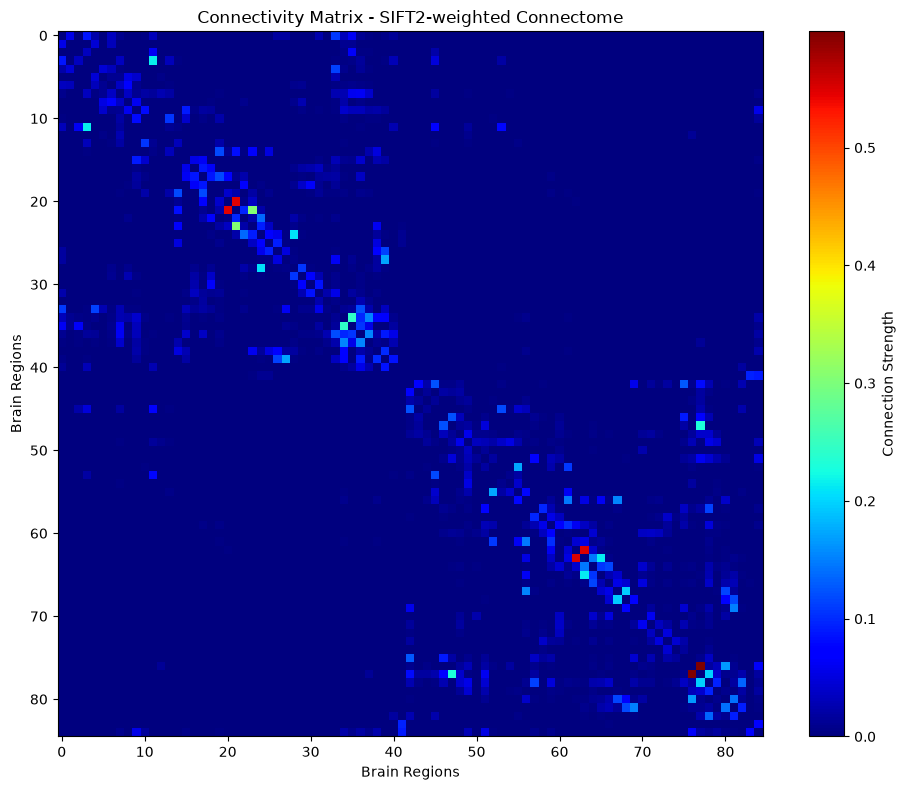

In [16]:
# ===================================================================
# --- Inspecting and Visualizing the Connectivity Matrix ---
# ===================================================================
# File existence checks - copy from processed directory if needed
if not os.path.exists(f"{os.environ['mrtrixDir']}/conn_matrix_sift2.csv"):
    !cp $derivDir_proc/mrtrix/conn_matrix_sift2.csv $mrtrixDir/
    
if not os.path.exists(f"{os.environ['mrtrixDir']}/parcellation_coreg_dseg.nii.gz"):
    !cp $derivDir_proc/mrtrix/parcellation_coreg_dseg.nii.gz $mrtrixDir/


import clabtoolkit.connectivitytools as cltconn
import clabtoolkit.parcellationtools as cltparc
import clabtoolkit.colorstools as cltcol
import os
import numpy as np

print("\n" + "="*70)
print("--- Loading and Inspecting Connectivity Matrix ---")
print("="*70 + "\n")

# Load the connectivity matrix for inspection
conn_mat_file = f"{mrtrixDir}/conn_matrix_sift2.csv"

# Load the connectivity matrix with Numpy
conn_matrix = np.loadtxt(conn_mat_file, delimiter=',')

# Computing the centroids of each region for potential future use
parc_file = f"{mrtrixDir}/parcellation_coreg_dseg.nii.gz"
parc = cltparc.Parcellation(parc_file)
cent_df = parc.compute_centroids()
region_coords = cent_df[['x_mm','y_mm','z_mm']].values   

# Creating a Connectome object for easier handling
connectome = cltconn.Connectome(conn_matrix, name="SIFT2-weighted Connectome", region_names=parc.name, region_colors=parc.color, region_coords=region_coords)

# Plotting the connectivity matrix
connectome.plot_matrix(cmap='jet', log_scale=False, figsize=(10,8))